## Columns to be removed from training/validation

In [1]:
disqualified_columns = ["tls_joint_isoitu_policy_crt_count", "rdap_time_from_last_change", "lex_www_flag"]

# Dataset preparation

In [2]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

from pyarrow import Table
from pandas import DataFrame, api, Int64Dtype
from pandas.core.dtypes import common as com
import sys
sys.path.append('..')
from utils.preprocess import NDF

def cast_timestamp(df: DataFrame):
    """
    Cast timestamp fields to seconds since epoch.
    """
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)

    return df


def union_tables(tables: [pa.Table]) -> pa.Table:
    union_table = tables[0]
    for table in tables[1:]:
        right_not_in_union = union_table.join(right_table=table, keys='domain_name', join_type='right anti',
                                              coalesce_keys=True, use_threads=True)
        union_table = pa.concat_tables([union_table, right_not_in_union])
    return union_table

##################################
# EDIT to specify the model name #
##################################
model_name = "phishing_xgboost_model_nonndf"     
##################################

# #############################################################
# EDIT this to specify benign / malicious datasets to use     #
# #############################################################
benign_dataset_filenames = [
    '../feature-extraction/floor/benign_2312.parquet',
    '../feature-extraction/floor/umbrella_benign_FINISHED.parquet'
]
malicious_dataset_filenames = [
    '../feature-extraction/floor/phishing_2406_strict.parquet',
]
# #############################################################
# EDIT this for to set appropriate labels (malware, dga, ...) #
# #############################################################
benign_label = "benign"
malicious_label = "phishing"
# #############################################################

# Unify malicious datasets and benign datasets
schema = (pq.read_table(malicious_dataset_filenames[0])).schema # Use the schema from the first malicious filename
benign_tables = [pq.read_table(filename).cast(schema) for filename in benign_dataset_filenames]

malicious_tables = [pq.read_table(filename).cast(schema) for filename in malicious_dataset_filenames]
malicious = union_tables(malicious_tables)
benign = union_tables(benign_tables)

# Convert pyarrow tables to pandas dataframes
df_benign = benign.to_pandas()
df_malicious = malicious.to_pandas()

# Set appropriate labels
df_benign["label"] = benign_label
df_malicious["label"] = malicious_label

# Merge the dataframes together
df = merged_df = pd.concat([df_benign, df_malicious], ignore_index=True)
class_map = {benign_label: 0, malicious_label: 1}

# Drop the domain name column
df.drop('domain_name', axis=1, inplace=True)

# Cast timestamps
df = cast_timestamp(df)

# Handle NaNs
df.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df.columns:
        df.drop(column, axis=1, inplace=True)
df

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


,label,dns_has_dnskey,dns_A_count,dns_AAAA_count,dns_MX_count,dns_NS_count,dns_TXT_count,dns_SOA_count,dns_CNAME_count,dns_zone_level,...,rdap_ip_v4_count,rdap_ip_v6_count,rdap_ip_shortest_v4_prefix_len,rdap_ip_longest_v4_prefix_len,rdap_ip_shortest_v6_prefix_len,rdap_ip_longest_v6_prefix_len,rdap_ip_avg_admin_name_len,rdap_ip_avg_admin_name_entropy,rdap_ip_avg_admin_email_len,rdap_ip_avg_admin_email_entropy
0,benign,0.0,0,0,0,0,0,0,1,0,...,1,0,19,19,0,0,15.000000,0.221549,0.000000,0.000000
1,benign,0.0,0,0,0,0,0,0,1,0,...,1,0,19,19,0,0,15.000000,0.221549,0.000000,0.000000
2,benign,1.0,1,1,1,4,2,1,0,0,...,7,6,17,24,48,48,11.384615,0.287974,3.538462,0.023059
3,benign,0.0,1,0,0,0,0,0,0,0,...,1,0,16,16,0,0,14.000000,0.231138,0.000000,0.000000
4,benign,0.0,1,0,0,0,0,0,0,0,...,1,0,16,16,0,0,14.000000,0.231138,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980744,phishing,0.0,1,0,0,2,0,1,0,0,...,17,2,13,16,22,22,6.210526,0.371952,23.894737,0.142238
980745,phishing,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000
980746,phishing,0.0,1,0,0,0,0,0,0,0,...,1,0,13,13,0,0,10.000000,0.292193,23.000000,0.157442
980747,phishing,0.0,1,1,0,0,2,0,0,0,...,1,1,21,21,48,48,10.000000,0.292193,23.000000,0.157442


In [ ]:
# Savethe dataframe for future analysis
SAVE_DF = False
if SAVE_DF:
    from pathlib import Path
    file_path = Path('./dataframes/phishing_extracted_features.csv')
    file_path.parent.mkdir(parents=True, exist_ok=True) 
    df.to_csv(file_path, index=False)

In [3]:
# Convert the unique feature names to a list
#feature_names_list = ndf_dataset['feature_names'].unique().tolist()

# Print each feature name individually
#for feature in feature_names_list:
#    print(feature)


# Model validation function

In [4]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, log_loss, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Helpers
from kneed import KneeLocator

def plot_metric(metric):
    plt.rcParams["figure.dpi"] = 300
    
    # Plot metric curves
    plt.plot(x_axis, results['training'][metric], label='Training set')
    plt.plot(x_axis, results['valid_1'][metric], label='Testing set')
    
    # Detect elbow using Kneedle algorithm
    kn = KneeLocator(x_axis, results['valid_1'][metric], curve='convex', direction='decreasing')
    if kn.knee:
        plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red', label='Elbow at tree ' + str(kn.knee))
    
    plt.legend()
    mnames = {'error': 'Classification Error', 'binary_logloss': 'Log Loss', 'auc': 'AUC'}
    mname = mnames.get(metric, metric)  # Return the metric itself if it's not in the dictionary
    plt.ylabel(mname)
    plt.xlabel('Number of trees')
    plt.title('LightGBM ' + mname)
    plt.show()

    
# Tuning - graphs
def DisplayTuningGraph(scores):
    from numpy import array
    from numpy.ma import masked_array

    col_names = ['mean_train_score', 'mean_test_score']
    means_df = scores[col_names]
    ax = means_df.plot(kind='line', grid=True)

    from matplotlib import pyplot as plt
    plt.rcParams["figure.figsize"] = [12, 12]
    plt.rcParams["figure.autolayout"] = True

    plt.rcParams["figure.dpi"] = 300

    max_ids = means_df.idxmax(axis=0)

    for i in range(len(max_ids)):
        for col_name in col_names:
            value = means_df[col_name][max_ids[i]]
            id = max_ids[i]

            color = 'r' if max_ids[i] == max_ids['mean_test_score'] else 'grey'

            ax.scatter([id], [value],
                      marker='o',
                      color=color,
                      label='point',)

            ax.annotate(str(round(value, 3))+"_ID="+str(id),
                        (id, value),
                        xytext=(id+3, value))
    print(scores)

def ValidateModel_advanced(X_test, y_test, model): 
    y_pred = model.predict(X_test)
    
    # Classification report
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    tn, fp, fn, tp = cm.ravel()
    print("Confusion Matrix:")
    print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

    # Plotting ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Model-specific evaluations
    if isinstance(model, (XGBClassifier, LGBMClassifier)):
        
        if isinstance(model, (XGBClassifier)):
            results = model.evals_result()
        elif isinstance(model, (LGBMClassifier)):
            results = model.evals_result_

        training_key = 'training' if isinstance(model, LGBMClassifier) else 'validation_0'
        validation_key = 'valid_1' if isinstance(model, LGBMClassifier) else 'validation_1'
        
        print("Training metrics:", results[training_key].keys())
        print("Validation metrics:", results[validation_key].keys())

        trees = len(results[validation_key]['binary_logloss']) if isinstance(model, LGBMClassifier) else len(results[validation_key]['logloss'])
        x_axis = range(0, trees)

        def plot_metric(metric):
            plt.rcParams["figure.dpi"] = 300

            # Plot metric curves
            plt.plot(x_axis, results[training_key][metric], label='Training set')
            plt.plot(x_axis, results[validation_key][metric], label='Validation set')

            # Detect elbow using Kneedle algorithm
            kn = KneeLocator(x_axis, results[validation_key][metric], curve='convex', direction='decreasing')
            if kn.knee:
                plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red', label='Elbow at tree ' + str(kn.knee))

            plt.legend()
            mnames = {'binary_logloss': 'Log Loss', 'auc': 'AUC'}
            mname = mnames.get(metric, metric)
            plt.ylabel(mname)
            plt.xlabel('Number of trees')
            plt.title(f'{type(model).__name__} {mname}')
            plt.show()

        if isinstance(model, LGBMClassifier):
            plot_metric('binary_logloss')
        elif isinstance(model, XGBClassifier):
            plot_metric('logloss')
            
        plot_metric('auc')
        
    elif isinstance(model, (RandomForestClassifier, AdaBoostClassifier)):
        # For RandomForest and AdaBoost, additional model-specific evaluations can be added here
        pass
    
    # Display the confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)  # Compute confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)  # Create display object
    disp.plot(cmap=plt.cm.Blues)  # Plot confusion matrix
    plt.show()  # Show the plot

## Supressing unwanted warnings (futures etc.)

In [5]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.*')
warnings.filterwarnings('ignore', category=FutureWarning, module='xgboost.*')
warnings.filterwarnings('ignore', message="Series.__getitem__ treating keys as positions is deprecated.*")

# XGBoost

# Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

labels = df['label'].apply(lambda x: class_map[x]) # y vector
features = df.drop('label', axis=1).copy() # X matrix

X_train, X_test, Y_train, Y_test = train_test_split(
  features,
  labels,
  test_size=0.2,
  random_state=42,
  shuffle=True, 
  stratify=labels
)

## XGBoost model Training

In [7]:
import joblib
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# XGBoost parameters
params = {        
    "objective": "binary:logistic",
    "tree_method": "hist",
    "sampling_method": "uniform",
    "max_depth": 10, 
    "eta": 0.04, 
    "min_child_weight": 1,
    "subsample": 0.6, 
    "alpha": 0, 
    "gamma": 0.06, 
    "lambda": 2.0, 
    "max_delta_step": 0, 
    "grow_policy": "depthwise",
    "max_bin": 512,
    "n_estimators": 150, 
    "scale_pos_weight": 0.01,
    "random_state": 42  # Set the seed for each run
}

# Create the XGBoost model
model = xgb.XGBClassifier(**params)

# Train the model
eval_set = [(X_train, Y_train), (X_test, Y_test)]
model.fit(X_train, Y_train, eval_set=eval_set, eval_metric=["error", "logloss", "auc"])

# Save the model to a file
joblib.dump(model, 'models/' + model_name + '.joblib')

[0]	validation_0-error:0.16765	validation_0-logloss:0.45388	validation_0-auc:0.73333	validation_1-error:0.16765	validation_1-logloss:0.45403	validation_1-auc:0.72979
[1]	validation_0-error:0.16765	validation_0-logloss:0.44683	validation_0-auc:0.73353	validation_1-error:0.16765	validation_1-logloss:0.44713	validation_1-auc:0.73001
[2]	validation_0-error:0.16765	validation_0-logloss:0.43980	validation_0-auc:0.80594	validation_1-error:0.16765	validation_1-logloss:0.44023	validation_1-auc:0.80317
[3]	validation_0-error:0.16765	validation_0-logloss:0.43349	validation_0-auc:0.81043	validation_1-error:0.16765	validation_1-logloss:0.43403	validation_1-auc:0.80743
[4]	validation_0-error:0.16765	validation_0-logloss:0.42805	validation_0-auc:0.81057	validation_1-error:0.16765	validation_1-logloss:0.42871	validation_1-auc:0.80756
[5]	validation_0-error:0.16765	validation_0-logloss:0.42301	validation_0-auc:0.81304	validation_1-error:0.16765	validation_1-logloss:0.42376	validation_1-auc:0.80964
[6]	

['models/phishing_xgboost_model_nonndf.joblib']

## LightGBM model Validation

              precision    recall  f1-score   support

           0     0.9440    0.9999    0.9712    163265
           1     0.9995    0.7056    0.8272     32885

    accuracy                         0.9506    196150
   macro avg     0.9718    0.8528    0.8992    196150
weighted avg     0.9533    0.9506    0.9470    196150

Confusion Matrix:
TN: 163253 FP: 12 FN: 9681 TP: 23204


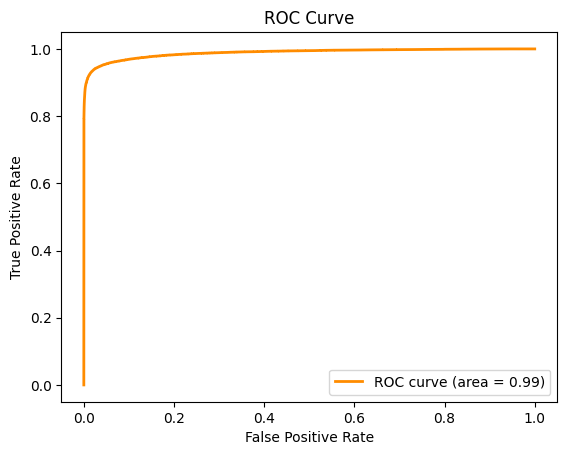

Training metrics: odict_keys(['error', 'logloss', 'auc'])
Validation metrics: odict_keys(['error', 'logloss', 'auc'])


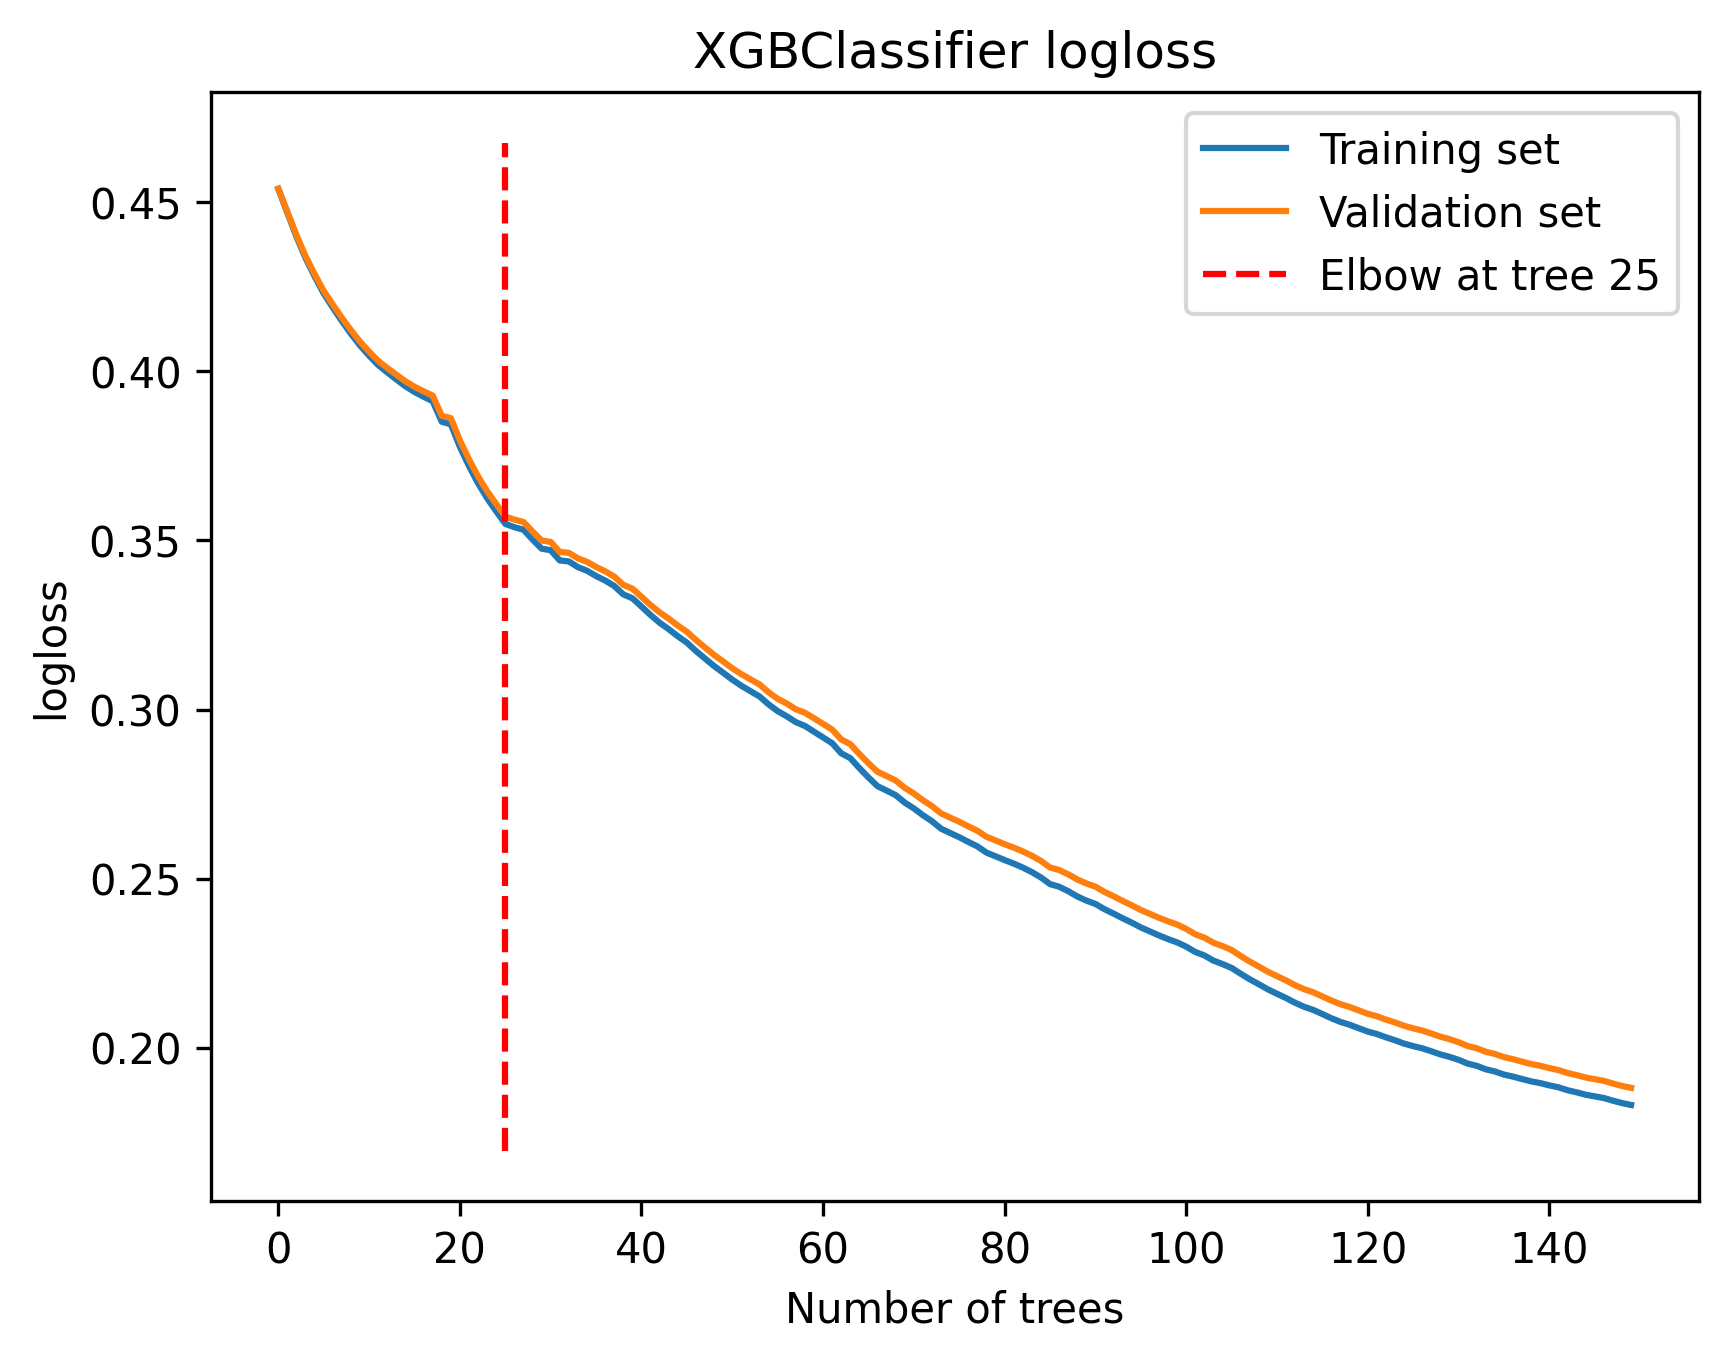

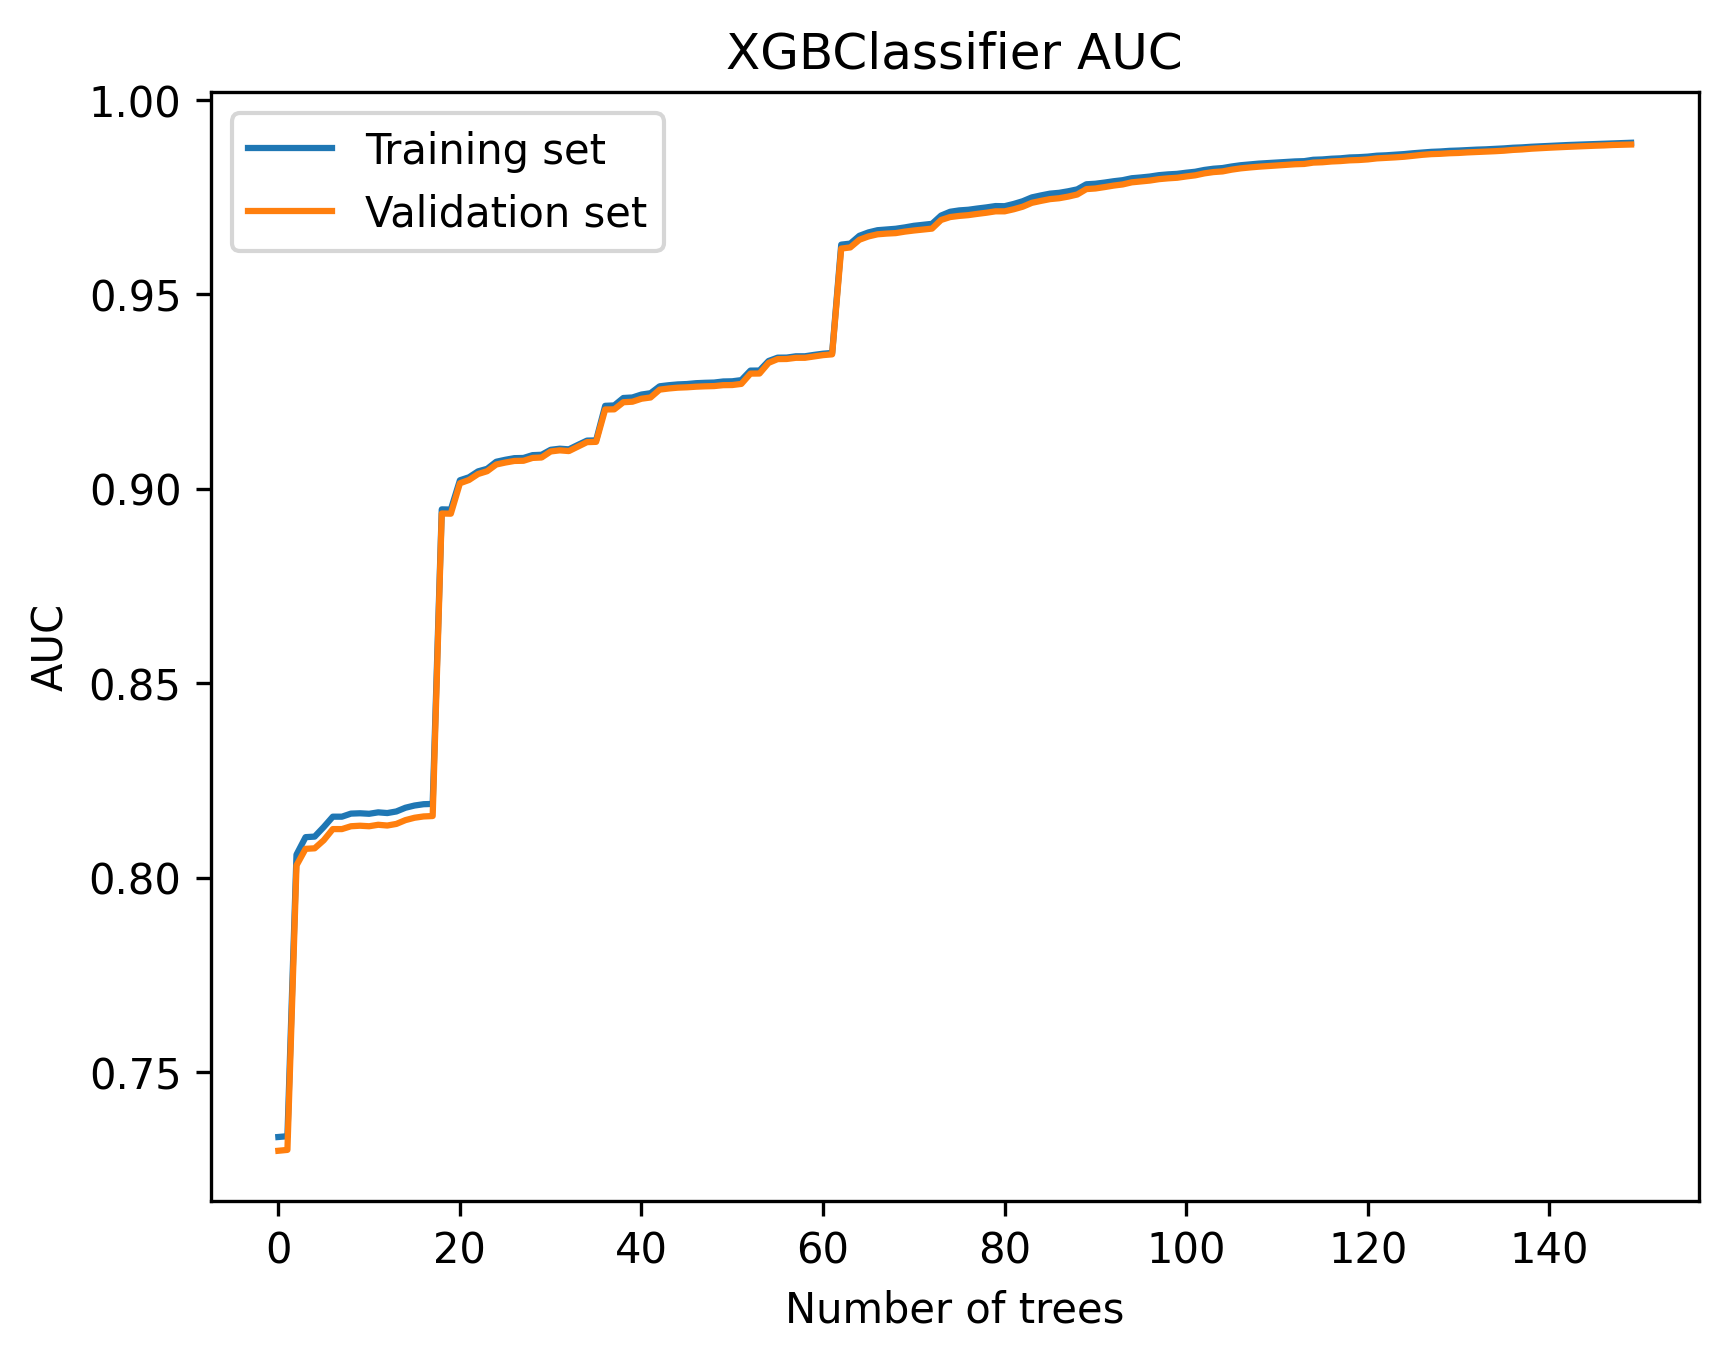

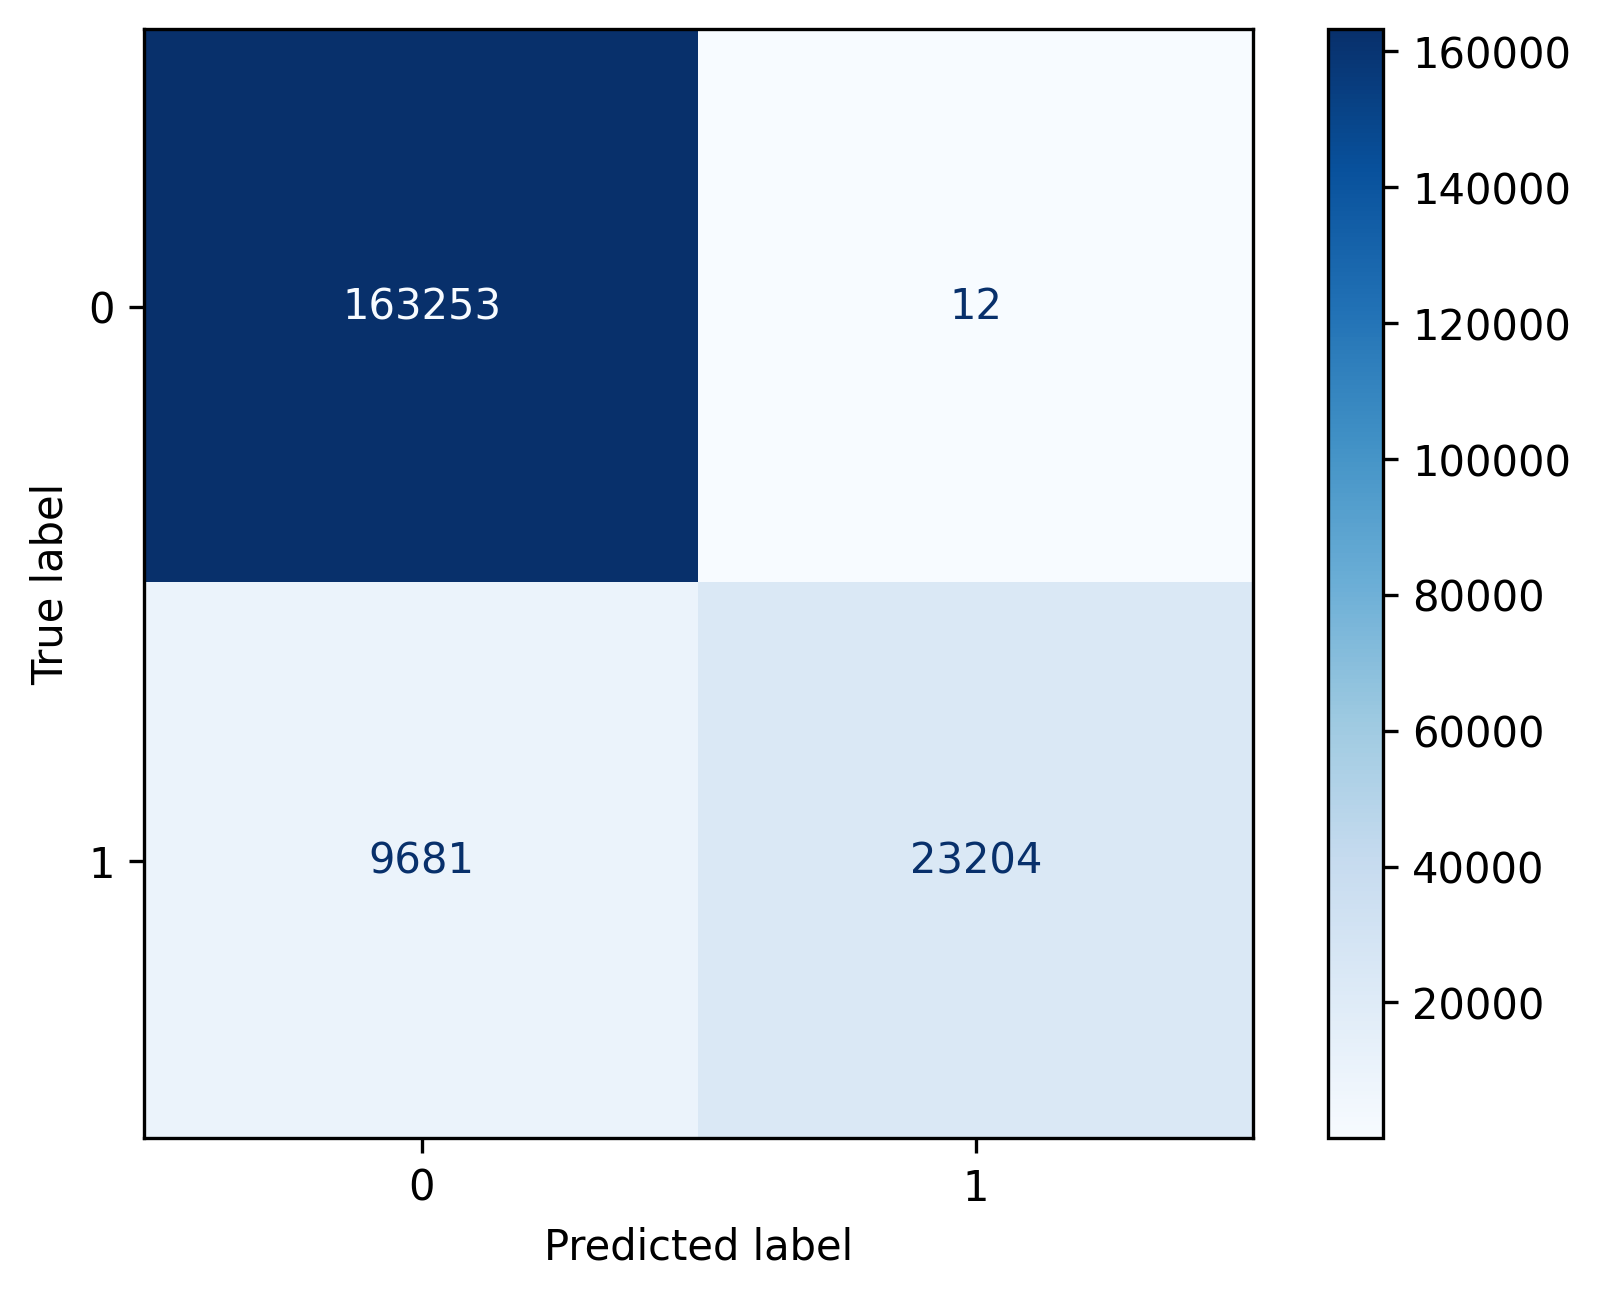

In [8]:
ValidateModel_advanced(X_test, Y_test, model)

## XGBoost model Tuning

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, log_loss

def FETA_Score(estimator, X, y):
    # Getting predictions
    y_pred = estimator.predict(X)
    y_pred_proba = estimator.predict_proba(X)
    
    # Calculating precision
    precision = precision_score(y, y_pred)
    
    # Calculating recall
    recall = recall_score(y, y_pred)
    
    # Calculating F1-score
    f1 = f1_score(y, y_pred)
    
    # Calculating FPR
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # Calculating Log Loss
    logloss = log_loss(y, y_pred_proba)
    
    # Estimating overfitting
    train_score = estimator.score(X_train, y_train) 
    validation_score = estimator.score(X, y) 
    overfitting = train_score - validation_score
    
    # Assigning weights
    w_precision = 0.1     # Precision
    w_recall = 0.1        # Recall
    w_f1 = 0.6            # F1
    w_fpr = -0.0          # Negative because lower FPR is better
    w_logloss = -0.0      # Negative because lower log loss is better
    w_overfitting = -0.2  # Negative because lower overfitting is better
    
    #w_precision = 0.0     # Precision
    #w_recall = 0.5        # Recall
    #w_f1 = 0.5            # F1
    #w_fpr = -0.0          # Negative because lower FPR is better
    #w_logloss = -0.1      # Negative because lower log loss is better
    #w_overfitting = -0.0  # Negative because lower overfitting is better
    
    # Assigning weights
    #w_precision = 0.1     # Precision
    #w_recall = 0.1        # Recall
    #w_f1 = 0.4            # F1
    #w_fpr = -0.1          # Negative because lower FPR is better
    #w_logloss = -0.1      # Negative because lower log loss is better
    #w_overfitting = -0.5  # Negative because lower overfitting is better
    
    # Combining metrics with weights
    combined_score = (w_precision * precision + w_recall * recall + w_f1 * f1 + w_fpr * fpr + w_overfitting * overfitting)
    
    return combined_score


In [10]:
xgb_tuning = False

if xgb_tuning:
    from xgboost import XGBClassifier
    from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
    import pandas as pd

    # Assuming df is your DataFrame and class_map maps your classes
    labels = df['label'].apply(lambda x: class_map[x])
    features = df.drop('label', axis=1).copy()

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42, shuffle=True, stratify=labels)

    params = {        
        "objective": "binary:logistic",
        "tree_method": "hist",
        "sampling_method": "gradient_based",
        "max_depth": 12, 
        "eta": 0.09787878787878787, 
        "min_child_weight": 1, 
        "subsample": 0.595959595959596, 
        "alpha": 0, 
        "gamma": 0.06060606060606061, 
        "lambda": 2.0707070707070705, 
        "max_delta_step": 0, 
        "grow_policy": "depthwise",
        "max_bin": 512,
        "n_estimators": 450, 
        #"scale_pos_weight": scale_pos_weight,
        "scale_pos_weight": 4.4864,
        "random_state": 42  # Set the seed for each run
    }

    
    # XGBoost base model
    xgb = XGBClassifier(**params)
    
    # Grid of parameters to search    
    grid = {
        #'scale_pos_weight': [4, 4.5, 5, 5.2, 6.28, 6, 6.71],
        'max_depth': [5, 7],
        'n_estimators': [10, 50, 150],
        #'scale_pos_weight': [6.35],
        # Add other parameters here if needed
    }
    

    # Stratified K-Folds cross-validator
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=7)

    # Grid Search
    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=grid,
        cv=cv,
        #scoring='f1',  # You can change this to another scoring method if needed
        scoring=FETA_Score,  # Custom metric
        verbose=3,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    # Best estimator
    best_xgb = grid_search.best_estimator_

    # Results
    scores = pd.DataFrame(grid_search.cv_results_)


In [11]:
a = ''
if xgb_tuning: 
    DisplayTuningGraph(scores)
    a = scores
a

''

## Testing on Validation Dataset

In [12]:
import pyarrow.parquet as pq
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import shap
from pandas.core.dtypes import common as com
import numpy as np

def cast_timestamp(df: pd.DataFrame):
    """
    Cast timestamp fields to seconds since epoch.
    """
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)
    return df

# Load the validation dataset
validation_dataset_filename = '../testdata/validation_phishing.parquet'
df_validation = pq.read_table(validation_dataset_filename).to_pandas()

# Cast timestamps and handle NaNs
df_validation = cast_timestamp(df_validation)
df_validation.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df_validation.columns:
        df_validation.drop(column, axis=1, inplace=True)

# Map the labels
df_validation['label'] = df_validation['label'].map({'benign': 0, 'phishing': 1})

# Extract features and labels
X_val = df_validation.drop(['label', 'domain_name'], axis=1)
y_val = df_validation['label']

# Load the trained model
model = joblib.load('models/' + model_name + '.joblib')

# Make predictions
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
weighted_accuracy = (accuracy_score(y_val[y_val == 0], y_pred[y_val == 0]) + accuracy_score(y_val[y_val == 1], y_pred[y_val == 1])) / 2
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

# Display metrics
print(f'Accuracy: {accuracy}')
print(f'Weighted Accuracy: {weighted_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'False Positive Rate: {false_positive_rate}')

# Display confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Identify misclassified domain names
misclassified = df_validation[y_val != y_pred]
misclassified_domains = misclassified['domain_name'].tolist()
print(f'Misclassified domains: {misclassified_domains}')

FileNotFoundError: ../testdata/validation_phishing.parquet

In [13]:
import shap

def display_shap_for_misclassified(model, misclassified, top_n=10):
    # Select the first N misclassified domains
    misclassified_subset = misclassified.head(top_n)

    # Extract features for the misclassified subset
    X_misclassified = misclassified_subset.drop(['label', 'domain_name'], axis=1)

    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_misclassified)

    # Plot SHAP values for the misclassified domains
    for i in range(len(misclassified_subset)):
        domain_name = misclassified_subset.iloc[i]['domain_name']
        print(f'Domain: {domain_name}')
        shap.initjs()
        shap.force_plot(explainer.expected_value, shap_values[i], X_misclassified.iloc[i], matplotlib=True)

# Display SHAP values for the first N misclassified domains
display_shap_for_misclassified(model, misclassified, top_n=30)


NameError: name 'misclassified' is not defined

# Advanced tuning - Training on Training portion, Validation on Validation dataset

In [14]:
advanced_tuning = False

if advanced_tuning:
    
    import pyarrow.parquet as pq
    import pandas as pd
    from sklearn.model_selection import GridSearchCV, PredefinedSplit
    from xgboost import XGBClassifier
    import joblib
    import numpy as np
    from pandas.core.dtypes import common as com
    
    # Function to cast timestamp fields
    def cast_timestamp(df: pd.DataFrame):
        """
        Cast timestamp fields to seconds since epoch.
        """
        for col in df.columns:
            if com.is_timedelta64_dtype(df[col]):
                df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
            elif com.is_datetime64_any_dtype(df[col]):
                df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)
        return df
    
    # Load the validation dataset
    validation_dataset_filename = '../testdata/validation_malware.parquet'
    df_validation = pq.read_table(validation_dataset_filename).to_pandas()
    
    # Drop disqualified columns if they exist
    for column in disqualified_columns:
        if column in df_validation.columns:
            df_validation.drop(column, axis=1, inplace=True)
    
    # Cast timestamps and handle NaNs
    df_validation = cast_timestamp(df_validation)
    df_validation.fillna(-1, inplace=True)
    
    # Map the labels
    df_validation['label'] = df_validation['label'].map({'benign': 0, 'malware': 1})
    
    # Extract features and labels from validation dataset
    X_val = df_validation.drop(['label', 'domain_name'], axis=1)
    y_val = df_validation['label']
    
    # Combine the training and validation datasets
    X_combined = pd.concat([X_train, X_val], ignore_index=True)
    y_combined = pd.concat([Y_train, y_val], ignore_index=True)
    
    # Create the test_fold array for PredefinedSplit
    train_size = len(X_train)
    test_size = len(X_val)
    test_fold = [-1] * train_size + [0] * test_size  # -1 for training, 0 for validation
    
    ps = PredefinedSplit(test_fold=test_fold)
    
    xgb_tuning = True  # Set to True to enable tuning
    
    if xgb_tuning:
        params = {        
            "objective": "binary:logistic",
            "tree_method": "hist",
            "sampling_method": "gradient_based",
            "max_depth": 10, 
            "eta": 0.04, 
            "min_child_weight": 1,
            "subsample": 0.6, 
            "alpha": 0, 
            "gamma": 0.06, 
            "lambda": 2.0, 
            "max_delta_step": 0, 
            "grow_policy": "depthwise",
            "max_bin": 512,
            "n_estimators": 600, 
            "scale_pos_weight": 0.01,
            "random_state": 42  # Set the seed for each run
        }
    
    
        clf = XGBClassifier(**params)
    
        # Grid of parameters to search through
        grid = {
            #"max_depth": [8, 9, 10, 11, 12],
            "n_estimators": [100, 200, 300, 400, 500]
            #"scale_pos_weight": [0.01, 0.05, 0.1, 0.2, 0.3],
            
            #"reg_alpha": [0, 0.11, 0.15, 0.2],
            #"reg_lambda": [0, 0.11, 0.15, 0.2],
            # Add other parameters to grid search if needed
            #"max_depth": [8, 9, 10],
            #"scale_pos_weight": [0.01, 0.05, 0.1, 0.2, 0.3],
            #"learning_rate": [0.03, 0.04, 0.05, 0.06],
        }
    
        grid_search = GridSearchCV(
            estimator=clf,
            param_grid=grid,
            cv=ps,
            scoring='f1',  # You can change this to another scoring method if needed
            verbose=3,
            return_train_score=True
        )
    
        grid_search.fit(X_combined, y_combined)
    
        clf = grid_search.best_estimator_
    
        scores = pd.DataFrame(grid_search.cv_results_)
        col_names = ['mean_train_score', 'mean_test_score']
    
        scores = pd.DataFrame(grid_search.cv_results_)
    
        # Save the best estimator
        joblib.dump(clf, 'models/' + model_name + '_best_xgboost.joblib')
    
        # Display the best parameters
        print("Best parameters found: ", grid_search.best_params_)
        print("Best score: ", grid_search.best_score_)
    
        # Plot the tuning results
        def DisplayTuningGraph(scores):
            means_df = scores[col_names]
            ax = means_df.plot(kind='line', grid=True)
    
            plt.rcParams["figure.figsize"] = [12, 12]
            plt.rcParams["figure.autolayout"] = True
            plt.rcParams["figure.dpi"] = 300
    
            max_ids = means_df.idxmax(axis=0)
    
            for i in range(len(max_ids)):
                for col_name in col_names:
                    value = means_df[col_name][max_ids[i]]
                    id = max_ids[i]
    
                    color = 'r' if max_ids[i] == max_ids['mean_test_score'] else 'grey'
    
                    ax.scatter([id], [value],
                               marker='o',
                               color=color,
                               label='point',)
    
                    ax.annotate(str(round(value, 3))+"_ID="+str(id),
                                (id, value),
                                xytext=(id+3, value))
            print(scores)
    
        DisplayTuningGraph(scores)


In [15]:
display = ''
if advanced_tuning:
    display = scores
display

''

# FP Debug

In [16]:
#FP DATASET
fp_dataset = '../testdata/xyz.parquet'
correct_label = 'benign'

In [17]:

# ---------- helper functions ----------
def cast_timestamp(df: pd.DataFrame):
    """Cast timestamp fields to seconds since epoch."""
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9
    return df

def _get_model_feature_names(model):
    try:
        booster = model.get_booster()
        if getattr(booster, "feature_names", None):
            return list(booster.feature_names)
    except Exception:
        pass
    if hasattr(model, "feature_name_"):
        return list(model.feature_name_)
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "steps"):
        try:
            return _get_model_feature_names(model.steps[-1][1])
        except Exception:
            pass
    return None

def _align_features(X: pd.DataFrame, required: list, fill_value=-1.0) -> pd.DataFrame:
    X = X.copy()
    if required is None:
        return (X.replace([np.inf, -np.inf], np.nan).fillna(fill_value))
    for f in required:
        if f not in X.columns:
            X[f] = fill_value
    X = X[[f for f in required]]
    X = (X.replace([np.inf, -np.inf], np.nan).fillna(fill_value))
    return X

def display_shap_for_misclassified(model, misclassified_df: pd.DataFrame, top_n=10, positive_class=1, top_k_features=15):
    """Render SHAP force plots for the first N misclassified domains (top-k features only)."""
    if misclassified_df.empty:
        print("No misclassified samples provided.")
        return

    subset = misclassified_df.head(top_n).copy()
    X = subset.drop(columns=[c for c in ['label', 'domain_name'] if c in subset.columns])

    req = _get_model_feature_names(model)
    X = _align_features(X, req, fill_value=-1.0)

    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        warnings.warn("TreeExplainer failed; using generic shap.Explainer.", RuntimeWarning)
        explainer = shap.Explainer(model, X, feature_names=list(X.columns))

    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        sv = shap_values[positive_class]
        expected_value = explainer.expected_value[positive_class]
    else:
        sv = shap_values
        expected_value = explainer.expected_value

    shap.initjs()

    for i in range(len(subset)):
        domain = subset.iloc[i]['domain_name'] if 'domain_name' in subset.columns else f"idx {i}"
        print(f"\nDomain: {domain}")

        # pick top-k features by absolute shap value
        vals = sv[i]
        feature_names = X.columns
        top_idx = np.argsort(np.abs(vals))[-top_k_features:]
        top_features = feature_names[top_idx]
        top_vals = vals[top_idx]
        top_sample = X.iloc[i, top_idx]

        # bigger figure
        plt.figure(figsize=(12, 3))
        shap.force_plot(expected_value, top_vals, top_sample, matplotlib=True, show=True)

Mean of empty slice.
invalid value encountered in scalar divide


Accuracy: 0.23076923076923078
Weighted Accuracy: nan
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
False Positive Rate: 0.7692307692307693


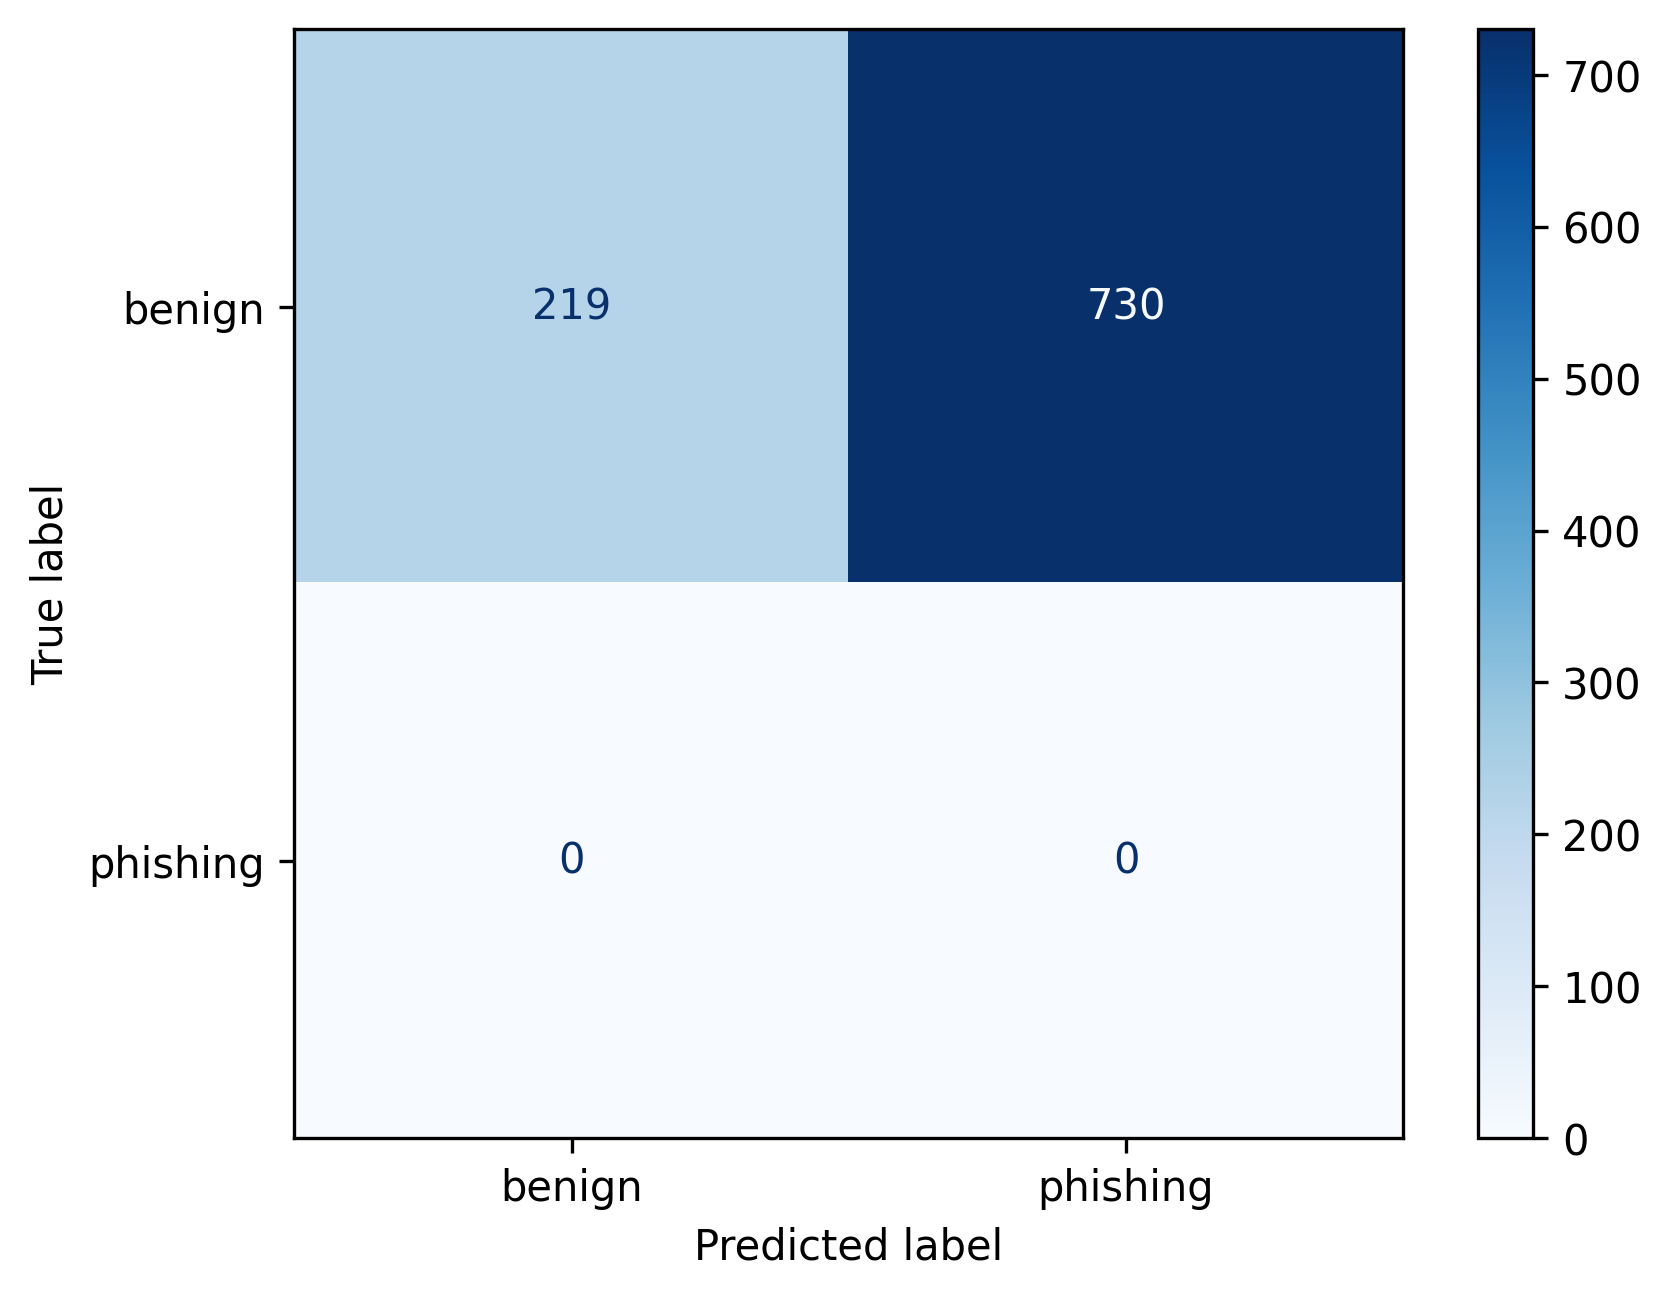

Misclassified domains: ['10bdmbet43.com', '11pornxxx.com', '123hdd.com', '123sss.net', '13d0jwj0azfgtb0ipfqp7xm.com', '14pg2.com', '14pg8.com', '168topgameb.com', '1hzaqfiu8ctr.com', '1x7bet.xyz', '2588989.com', '2aksestukul.pro', '2wgaming.com', '3patticrown.net', '42pg10.com', '48ninecasino16.com', '4iki.net', '53pgdd.com', '59249300.com', '599k11.com', '5uc4ewsxzu.com', '66llottery.org', '66uba.com', '67spinmama42.com', '72pgdd.com', '777boijogo.com', '78wint.com', '88pulsadex.com', '8etpro.com', '8hq9yqttr5smjpyuythnteh.com', '8toptrend.com', '95cemara777.com', '99004001.com', '99tg9e.com', '9kbet031.com', 'a6663.com', 'a6bet8.com', 'aa888.pw', 'abbathemuseum.com', 'aceh4dterbaik.pro', 'acenewshub.com', 'adtrackcorp.com', 'adzkialearningcenter.com', 'aethrascans.com', 'agen89pizza.com', 'agenqris.xyz', 'ahaneiro6.com', 'ahazzfundsllc.com', 'airbet88-juara.live', 'airbet88-tergacor.xyz', 'airbornerf.com', 'ajephhxupldcrr84tbc.com', 'ajslot88gryphon.xyz', 'ajudanfounder88.com', 'al7l

In [18]:
# ---------- main evaluation pipeline ----------
# Load the validation dataset
df_validation = pq.read_table(fp_dataset).to_pandas()
df_validation["label"] = correct_label

# Drop all columns starting with "html_"
df_validation = df_validation.drop(columns=[c for c in df_validation.columns if c.startswith("html_")])

# Cast timestamps and handle NaNs
df_validation = cast_timestamp(df_validation)
df_validation.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df_validation.columns:
        df_validation.drop(column, axis=1, inplace=True)

# Map the labels
df_validation['label'] = df_validation['label'].map({'benign': 0, 'phishing': 1})

# Extract features and labels
X_val = df_validation.drop(['label', 'domain_name'], axis=1)
y_val = df_validation['label']

# Load the trained model
model = joblib.load('models/' + model_name + '.joblib')

# Align features
required_features = _get_model_feature_names(model)
if required_features is not None:
    X_val = _align_features(X_val, required_features, fill_value=-1.0)
else:
    warnings.warn("Could not determine model feature names automatically; proceeding without reordering.", RuntimeWarning)

# Make predictions
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Metrics
accuracy = accuracy_score(y_val, y_pred)
weighted_accuracy = (accuracy_score(y_val[y_val == 0], y_pred[y_val == 0]) +
                     accuracy_score(y_val[y_val == 1], y_pred[y_val == 1])) / 2
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

print(f'Accuracy: {accuracy}')
print(f'Weighted Accuracy: {weighted_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'False Positive Rate: {false_positive_rate}')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Misclassified domains
misclassified = df_validation[y_val != y_pred]
misclassified_domains = misclassified['domain_name'].tolist()
print(f'Misclassified domains: {misclassified_domains}')

# ---- NEW: SHAP force plots for first 10 misclassified ----
# display_shap_for_misclassified(model, misclassified, top_n=20)

In [19]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import warnings

def plot_top_problematic_features(model, misclassified_df: pd.DataFrame, top_k=10, positive_class=1):
    """
    Plot Top-K problematic features for misclassified domains using SHAP.
    'Problematic' = highest average positive SHAP value (push toward class=1) over misclassified samples.

    Assumes your helper functions _get_model_feature_names and _align_features are defined.
    Columns 'label' and 'domain_name' (if present) are excluded from X.
    """

    if misclassified_df.empty:
        print("No misclassified samples to analyze.")
        return

    # Build feature matrix from misclassified rows
    X = misclassified_df.drop(columns=[c for c in ["label", "domain_name"] if c in misclassified_df.columns])

    # Align features to model schema (if known)
    req = _get_model_feature_names(model)
    X = _align_features(X, req, fill_value=-1.0)

    # SHAP explainer (tree models -> TreeExplainer, else generic)
    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        warnings.warn("TreeExplainer failed; falling back to shap.Explainer.", RuntimeWarning)
        explainer = shap.Explainer(model, X, feature_names=list(X.columns))

    shap_values = explainer.shap_values(X)

    # Handle binary outputs
    if isinstance(shap_values, list):
        sv = np.array(shap_values[positive_class])   # (n_samples, n_features)
    else:
        sv = np.array(shap_values)                   # (n_samples, n_features)

    # We define "problematic" as contribution pushing toward phishing (class 1)
    # -> take only positive SHAP values per feature, average across misclassified samples
    sv_pos = np.where(sv > 0, sv, 0.0)
    mean_pos_contrib = sv_pos.mean(axis=0)  # (n_features,)

    # Find top-K features
    feature_names = np.array(X.columns)
    top_idx = np.argsort(mean_pos_contrib)[-top_k:][::-1]
    top_feats = feature_names[top_idx]
    top_vals  = mean_pos_contrib[top_idx]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top_feats)), top_vals)
    plt.yticks(range(len(top_feats)), top_feats)
    plt.gca().invert_yaxis()
    plt.xlabel("Average positive SHAP contribution (push toward phishing)")
    plt.title(f"Top {top_k} problematic features for misclassified domains")
    plt.tight_layout()
    plt.show()

    # Also return a DataFrame for reference / saving
    return pd.DataFrame({"feature": top_feats, "avg_positive_shap": top_vals})

# ---- Usage (after you computed `misclassified` and loaded `model`) ----
# top_df = plot_top_problematic_features(model, misclassified, top_k=10, positive_class=1)
# print(top_df)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- helpers to extract thresholds from tree models ---

def _xgb_feature_thresholds(model, features):
    """Return {feature: [thresholds...]} for XGBoost models."""
    try:
        booster = model.get_booster()
        # trees_to_dataframe is convenient and robust
        df_trees = booster.trees_to_dataframe()
        out = {}
        for feat in features:
            ths = df_trees.loc[df_trees['Feature'] == feat, 'Split'].dropna().astype(float).tolist()
            if ths:
                out[feat] = ths
        return out
    except Exception:
        return {}

def _lgbm_feature_thresholds(model, features):
    """Return {feature: [thresholds...]} for LightGBM models."""
    # accept sklearn.LGBM* or raw Booster
    booster = getattr(model, "booster_", model)
    try:
        dump = booster.dump_model()
        out = {f: [] for f in features}
        for tree in dump.get("tree_info", []):
            # recursive scan of nodes
            stack = [tree.get("tree_structure", {})]
            while stack:
                node = stack.pop()
                if "split_feature" in node:
                    feat_name = node.get("split_feature_name")
                    thr = node.get("threshold")
                    if feat_name in out and thr is not None:
                        try:
                            out[feat_name].append(float(thr))
                        except Exception:
                            pass
                    if "left_child" in node:  stack.append(node["left_child"])
                    if "right_child" in node: stack.append(node["right_child"])
        # drop empties
        out = {k: v for k, v in out.items() if v}
        return out
    except Exception:
        return {}

def extract_feature_thresholds(model, features, agg="median"):
    """
    Extract per-feature decision thresholds from tree splits.
    Returns DataFrame with columns: feature, threshold (aggregated).
    """
    thresholds = {}
    # try XGBoost then LightGBM
    xgb = _xgb_feature_thresholds(model, features)
    lgb = _lgbm_feature_thresholds(model, features)
    # merge (prefer xgb if both present)
    merged = {**lgb, **xgb, **lgb}
    if not merged:
        warnings.warn("Could not extract thresholds from model (non-tree model or unsupported).", RuntimeWarning)
        return pd.DataFrame({"feature": features, "threshold": [np.nan]*len(features)})

    for feat in features:
        vals = merged.get(feat, [])
        if not vals:
            thresholds[feat] = np.nan
        else:
            if   agg == "median": thresholds[feat] = float(np.median(vals))
            elif agg == "mean":  thresholds[feat] = float(np.mean(vals))
            elif agg == "min":   thresholds[feat] = float(np.min(vals))
            elif agg == "max":   thresholds[feat] = float(np.max(vals))
            else:                thresholds[feat] = float(np.median(vals))
    return pd.DataFrame({"feature": list(thresholds.keys()), "threshold": list(thresholds.values())})

# --- your analysis function, now with thresholds overlayed ---

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# --- canonical analyzer: always returns a DataFrame (with a 'suggestion' column) ---
def analyze_problematic_features(
    model,
    df_validation,
    misclassified,                # DataFrame of misclassified rows OR boolean mask OR index-like
    top_k=10,
    positive_class=1,             # kept for API compatibility
    agg_threshold="median",
):
    """
    Returns a dict: {feature: {
        'threshold', 'phishing_side', 'mis_mean', 'correct_mean',
        'mis_on_phishing_side', 'mis_on_phishing_side_pct', 'suggestion'
    }}
    Also plots distributions with the threshold line.
    """

    # --- Normalize misclassified into a DataFrame aligned with df_validation ---
    if isinstance(misclassified, pd.DataFrame):
        mis_df_all = misclassified.copy()
        mis_idx = mis_df_all.index
    elif isinstance(misclassified, (pd.Series, np.ndarray, list, pd.Index)):
        if isinstance(misclassified, pd.Series) and misclassified.dtype == bool:
            mis_idx = df_validation.index[misclassified.values]
        else:
            mis_idx = pd.Index(misclassified)
        mis_df_all = df_validation.loc[mis_idx]
    else:
        raise TypeError("`misclassified` must be a DataFrame, boolean mask, index/ids, or Series.")

    # --- Safety: need numeric label 0/1 present ---
    if "label" not in df_validation.columns:
        raise ValueError("df_validation must contain a numeric 'label' column (0/1).")

    # --- Pick top_k features to inspect.
    #     If you have your own function plot_top_problematic_features, use it; otherwise fallback to variance.
    top_features = None
    if "plot_top_problematic_features" in globals():
        top_df = plot_top_problematic_features(model, mis_df_all, top_k=top_k, positive_class=positive_class)
        top_features = top_df["feature"].tolist()
    else:
        # fallback: take top_k by variance among misclassified rows
        numeric_cols = [c for c in df_validation.columns if c not in ("label", "domain_name")]
        mis_var = (pd.to_numeric(mis_df_all[numeric_cols], errors="coerce")
                     .var(axis=0, skipna=True).sort_values(ascending=False))
        top_features = mis_var.head(top_k).index.tolist()

    # --- Benign subsets (correct vs misclassified) ---
    benign_all = df_validation[df_validation["label"] == 0]
    if "domain_name" in df_validation.columns and "domain_name" in mis_df_all.columns:
        benign_misclass = mis_df_all[mis_df_all["label"] == 0]
        benign_correct = benign_all[~benign_all["domain_name"].isin(benign_misclass["domain_name"])]
    else:
        benign_misclass = benign_all.loc[benign_all.index.intersection(mis_df_all.index)]
        benign_correct = benign_all.loc[benign_all.index.difference(mis_df_all.index)]

    # --- Model thresholds for these features ---
    thr_df = extract_feature_thresholds(model, top_features, agg=agg_threshold)
    thr_map = dict(zip(thr_df["feature"], thr_df["threshold"]))

    results = {}

    for feat in top_features:
        if feat not in benign_all.columns:
            warnings.warn(f"Feature '{feat}' not in validation DF; skipping.", RuntimeWarning)
            continue

        vals_corr = pd.to_numeric(benign_correct[feat], errors="coerce").astype(float)
        vals_mis  = pd.to_numeric(benign_misclass[feat], errors="coerce").astype(float)

        mis_mean  = float(np.nanmean(vals_mis))  if len(vals_mis)  else np.nan
        corr_mean = float(np.nanmean(vals_corr)) if len(vals_corr) else np.nan

        t = thr_map.get(feat, np.nan)

        # Heuristic: if mis_mean > corr_mean, treat ">" as phishing side; else "<="
        if np.isnan(mis_mean) or np.isnan(corr_mean):
            phishing_side = ">" if not np.isnan(t) else "<="
        else:
            phishing_side = ">" if mis_mean > corr_mean else "<="

        if np.isnan(t):
            on_phish_side = None
            pct_phish_side = None
        else:
            if phishing_side == ">":
                on_phish_side = int(np.nansum(vals_mis > t))
            else:
                on_phish_side = int(np.nansum(vals_mis <= t))
            denom = int(np.sum(~np.isnan(vals_mis)))
            pct_phish_side = (on_phish_side / denom) if denom else None

        # Human-friendly suggestion
        if not np.isnan(t):
            suggestion = (
                f"[{feat}] threshold≈{t:.3g} | phishing side: value {phishing_side} threshold | "
                f"mis_mean={mis_mean:.3g}, correct_mean={corr_mean:.3g} | "
                f"mis on phishing side: {on_phish_side}/{len(vals_mis)} "
                f"({(pct_phish_side or 0)*100:.1f}%)"
            )
        else:
            suggestion = (
                f"[{feat}] No threshold extracted; mis_mean={mis_mean:.3g}, "
                f"correct_mean={corr_mean:.3g}"
            )

        # ---- Plot KDEs + threshold line ----
        plt.figure(figsize=(8, 4))
        sns.kdeplot(vals_corr.dropna(), label="Correct benign", fill=True, alpha=0.35)
        sns.kdeplot(vals_mis.dropna(),  label="Misclassified benign", fill=True, alpha=0.35)
        if not np.isnan(t):
            plt.axvline(t, linestyle="--", linewidth=2, label=f"Model threshold ≈ {t:.3g}")
            plt.text(t, plt.ylim()[1]*0.9, f"Phishing side: value {phishing_side} threshold",
                     rotation=90, va="top", ha="left")
        plt.title(f"Feature: {feat}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        results[feat] = {
            "threshold": t,
            "phishing_side": phishing_side,
            "mis_mean": mis_mean,
            "correct_mean": corr_mean,
            "mis_on_phishing_side": on_phish_side,
            "mis_on_phishing_side_pct": float(pct_phish_side) if pct_phish_side is not None else None,
            "suggestion": suggestion,
        }

    return results

# --- tiny helpers for full backward-compatibility ---
def analysis_to_dict(analysis_df: pd.DataFrame):
    """Convert the canonical DataFrame into {feature: {...}} (legacy shape)."""
    return (analysis_df.set_index("feature")
                       .apply(lambda r: {k: (None if (isinstance(r[k], float) and np.isnan(r[k])) else r[k])
                                         for k in analysis_df.columns if k != "feature"}, axis=1)
                       .to_dict())

def print_suggestions(analysis):
    """Print suggestions whether `analysis` is a dict or a DataFrame."""
    if isinstance(analysis, pd.DataFrame):
        if "suggestion" in analysis.columns:
            for _, row in analysis.iterrows():
                print(row["suggestion"])
        else:
            for _, row in analysis.iterrows():
                print(row.to_dict())
    elif isinstance(analysis, dict):
        for feat, info in analysis.items():
            print(info.get("suggestion", f"{feat}: {info}"))
    else:
        raise TypeError("analysis must be a DataFrame or dict")

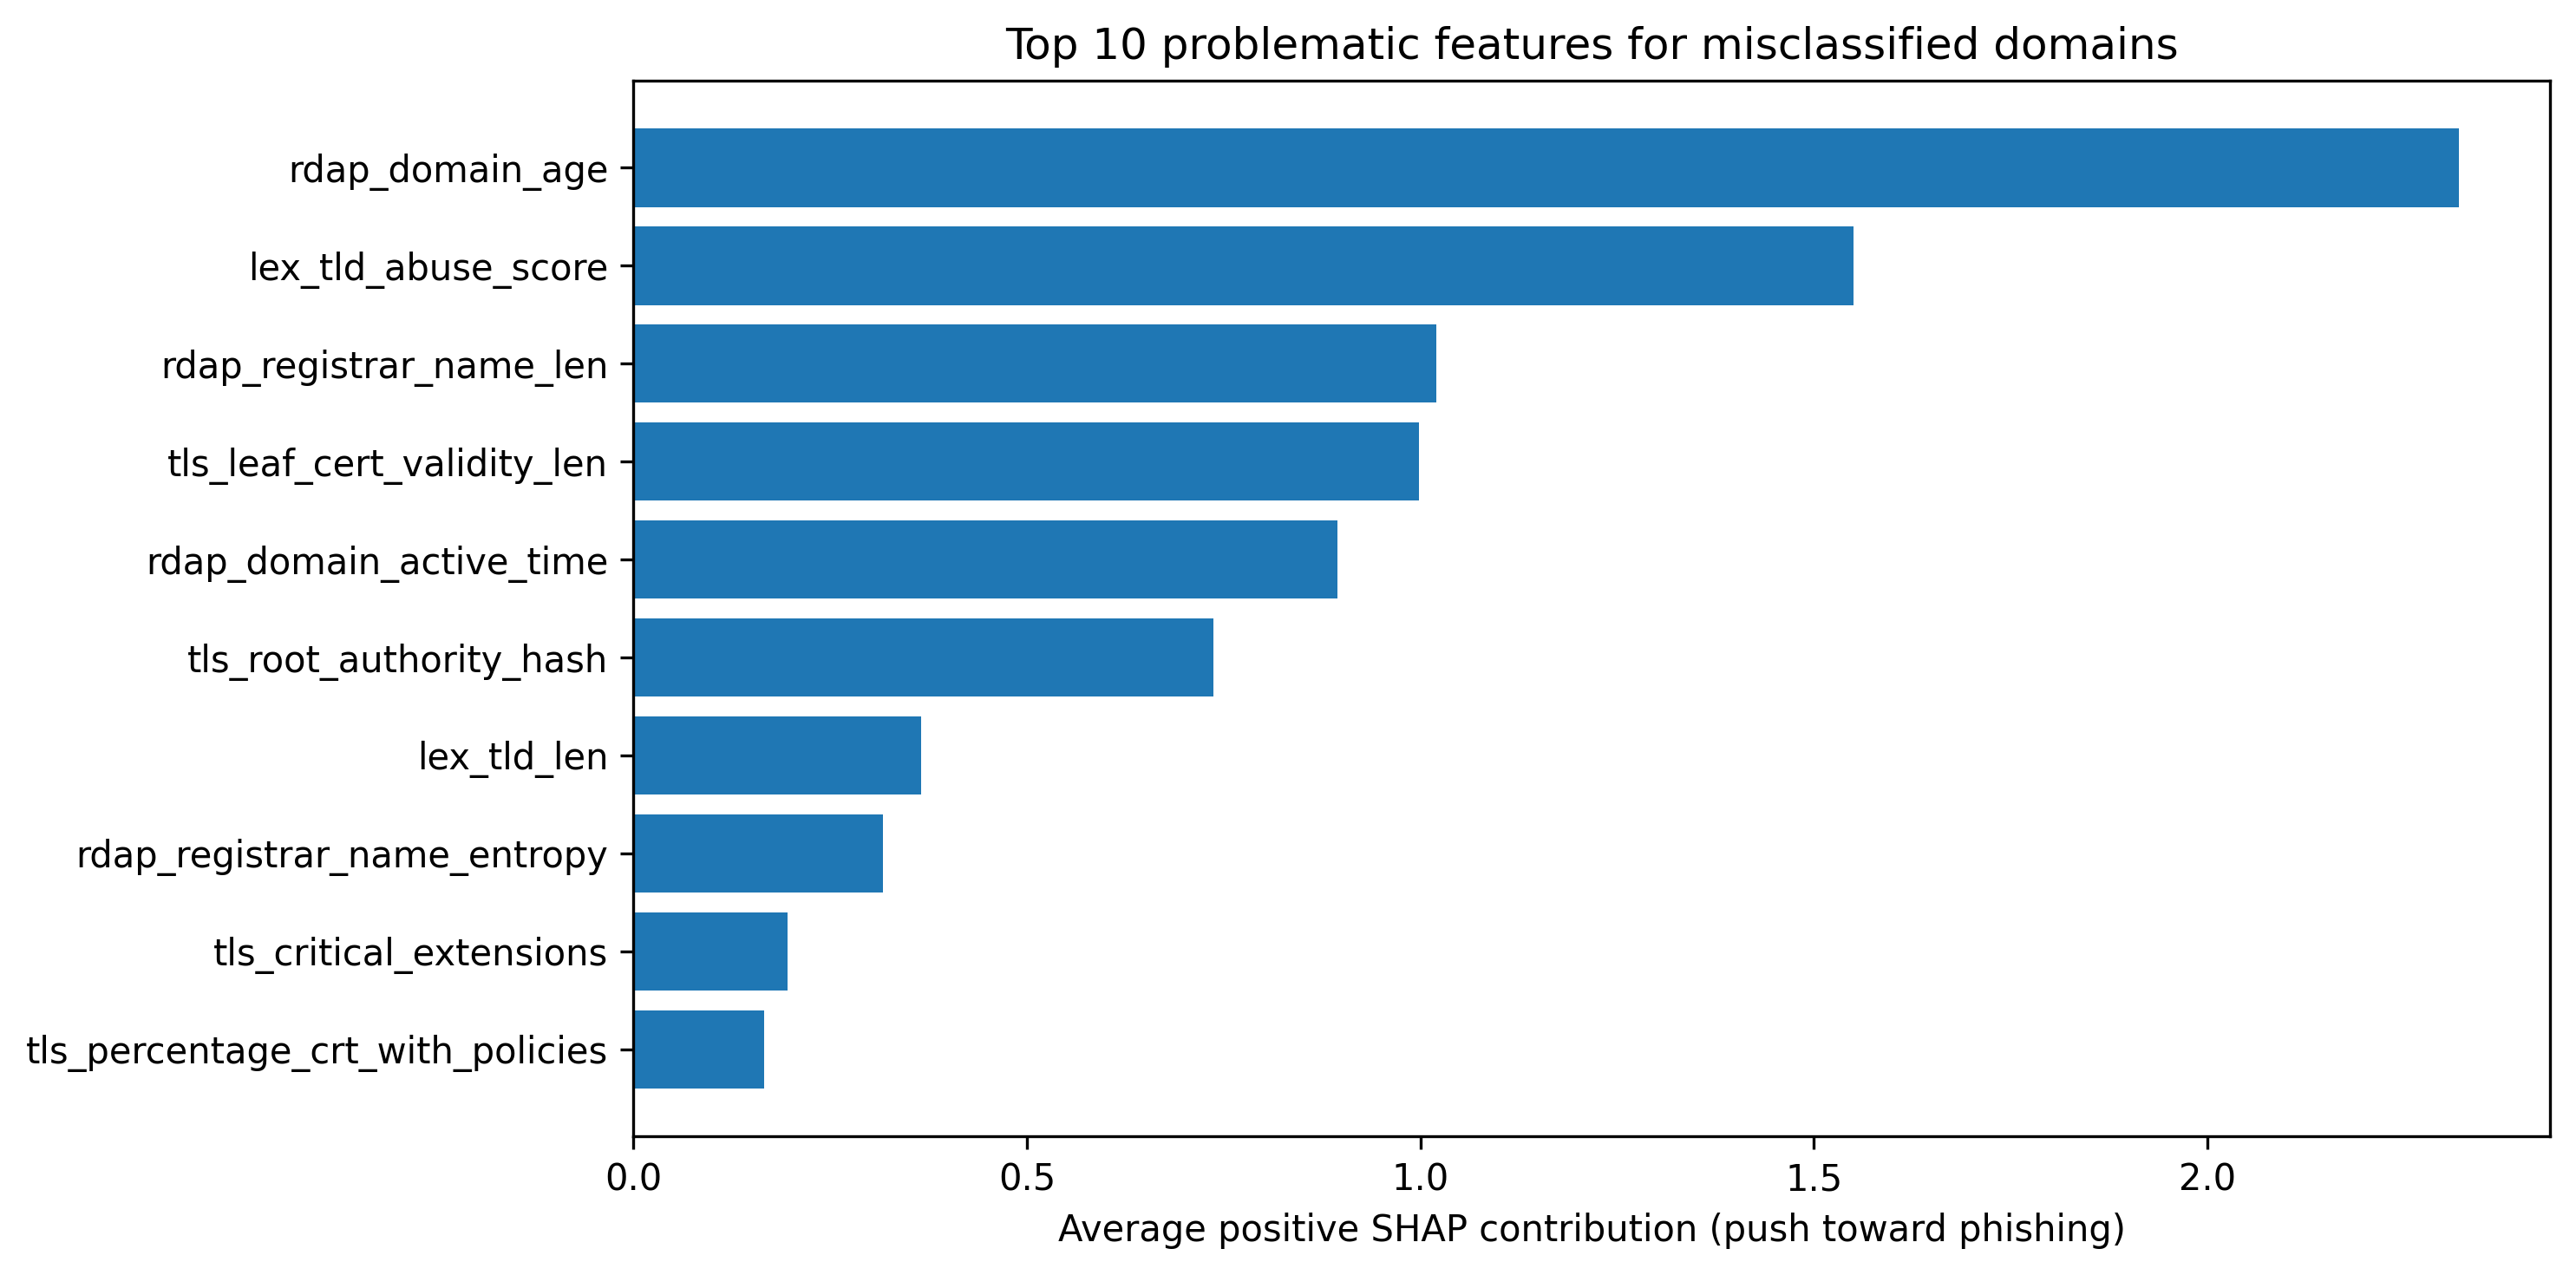

Could not extract thresholds from model (non-tree model or unsupported).


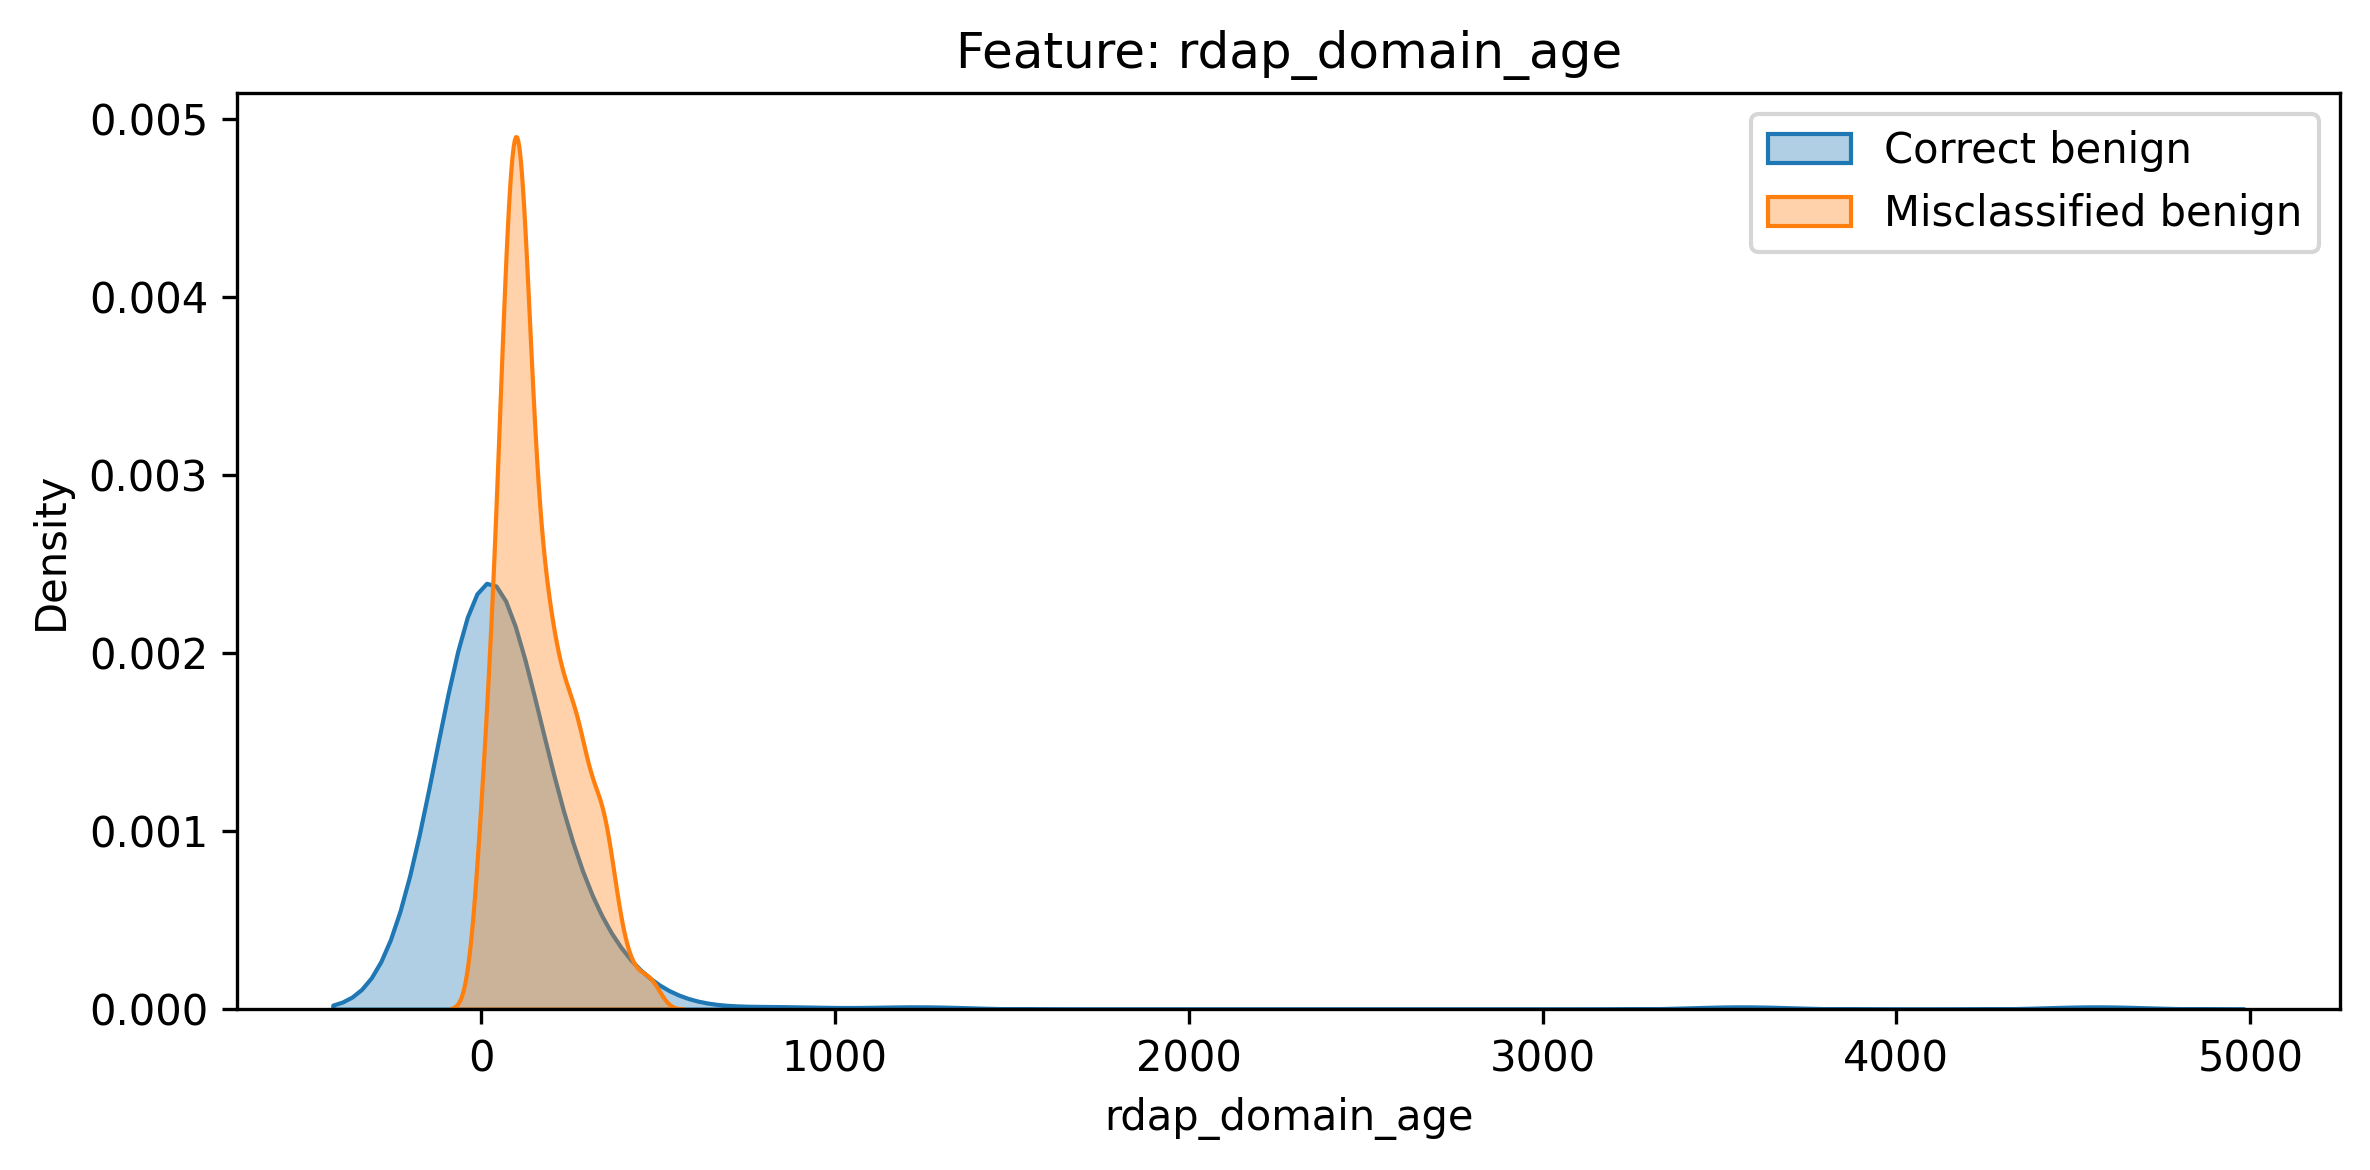

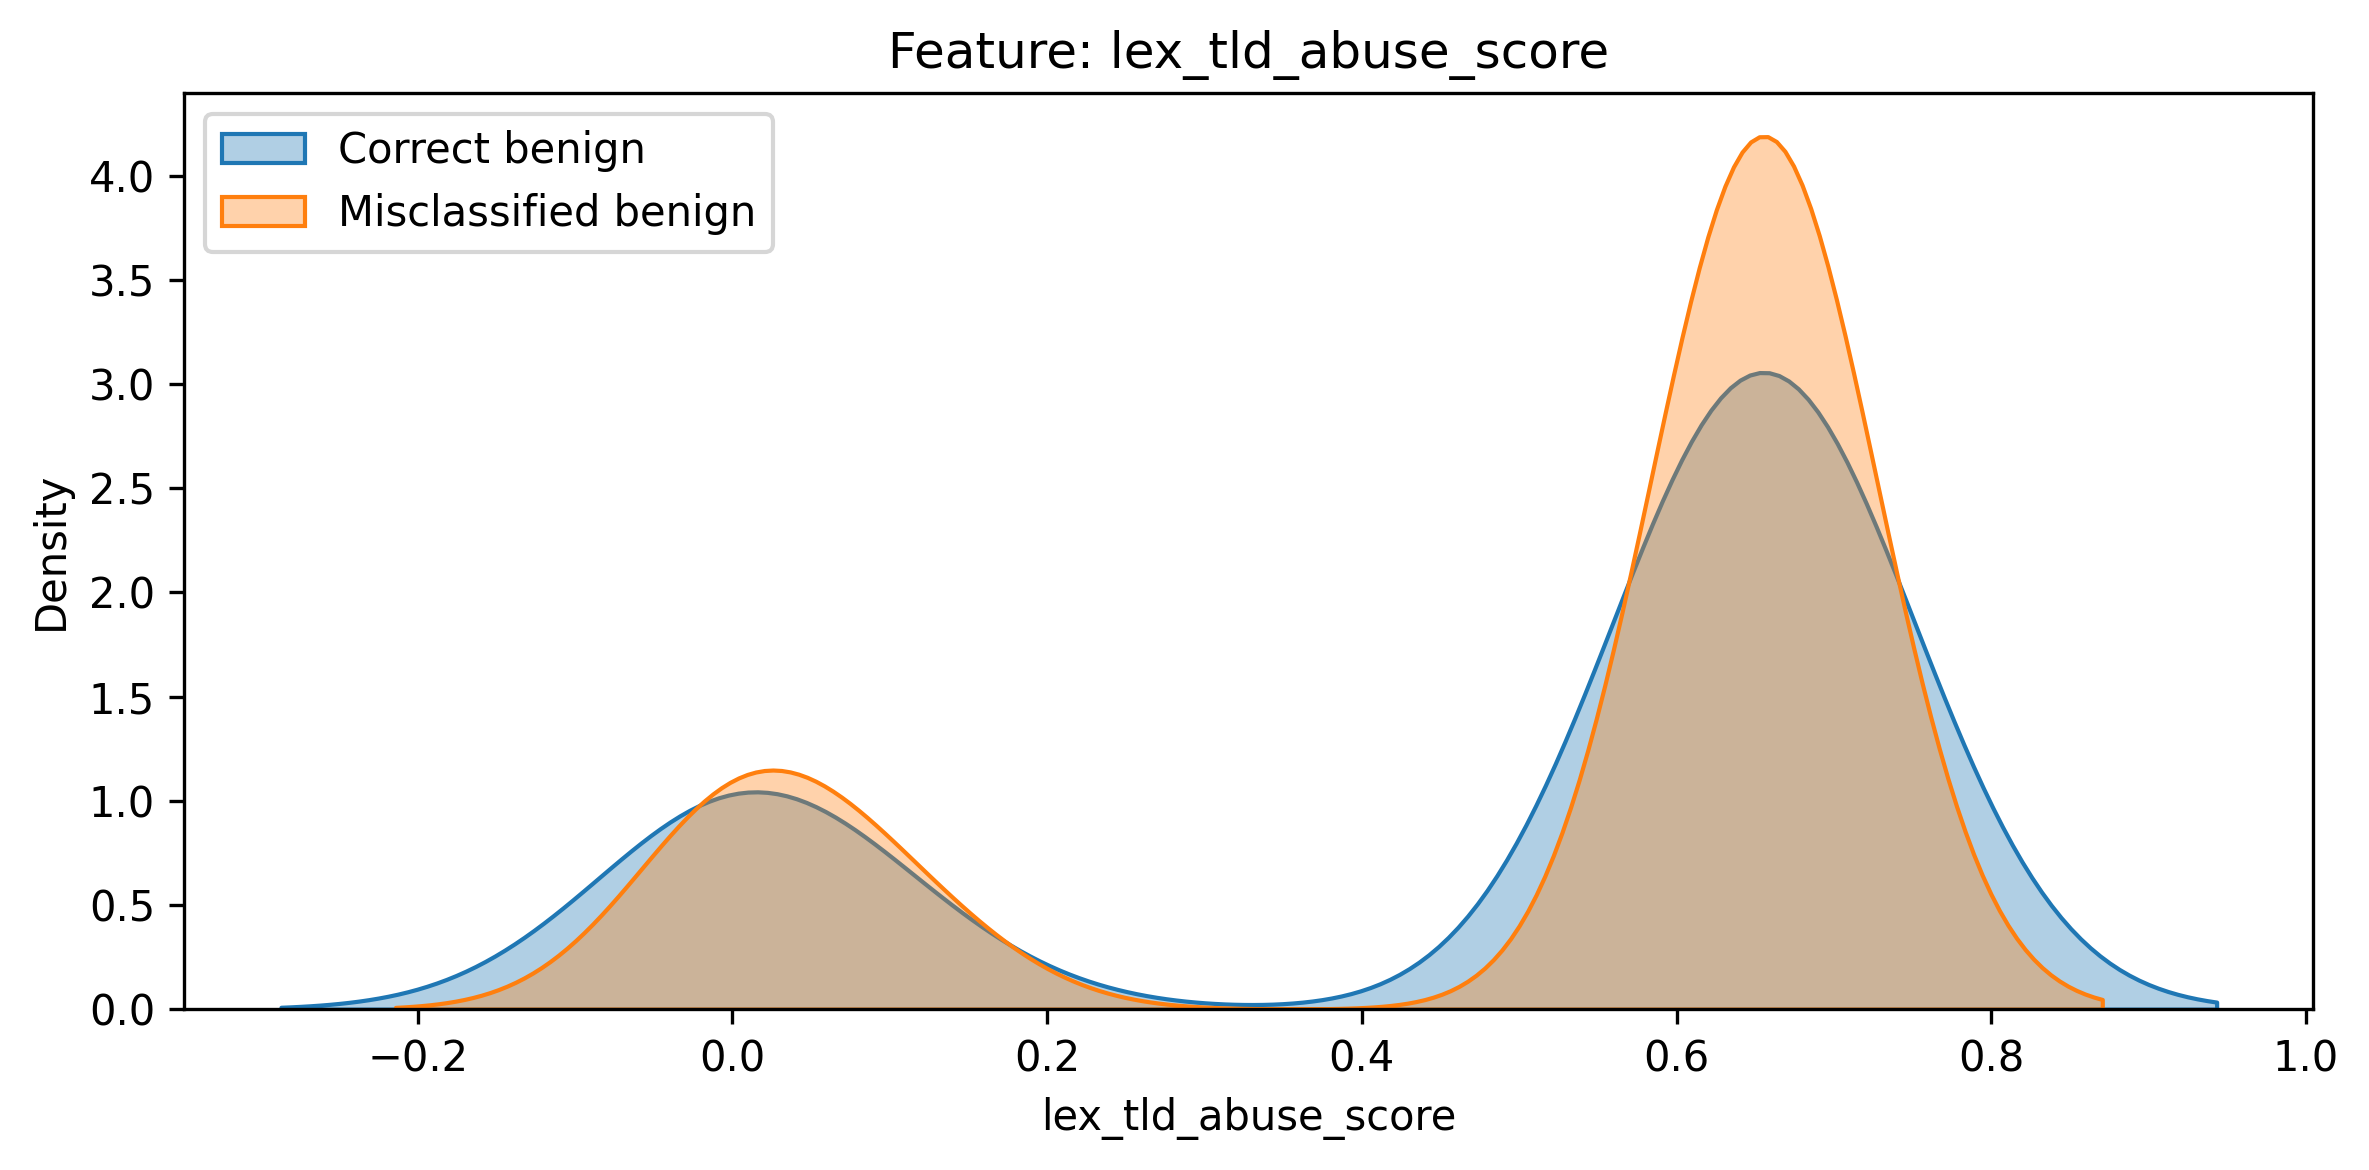

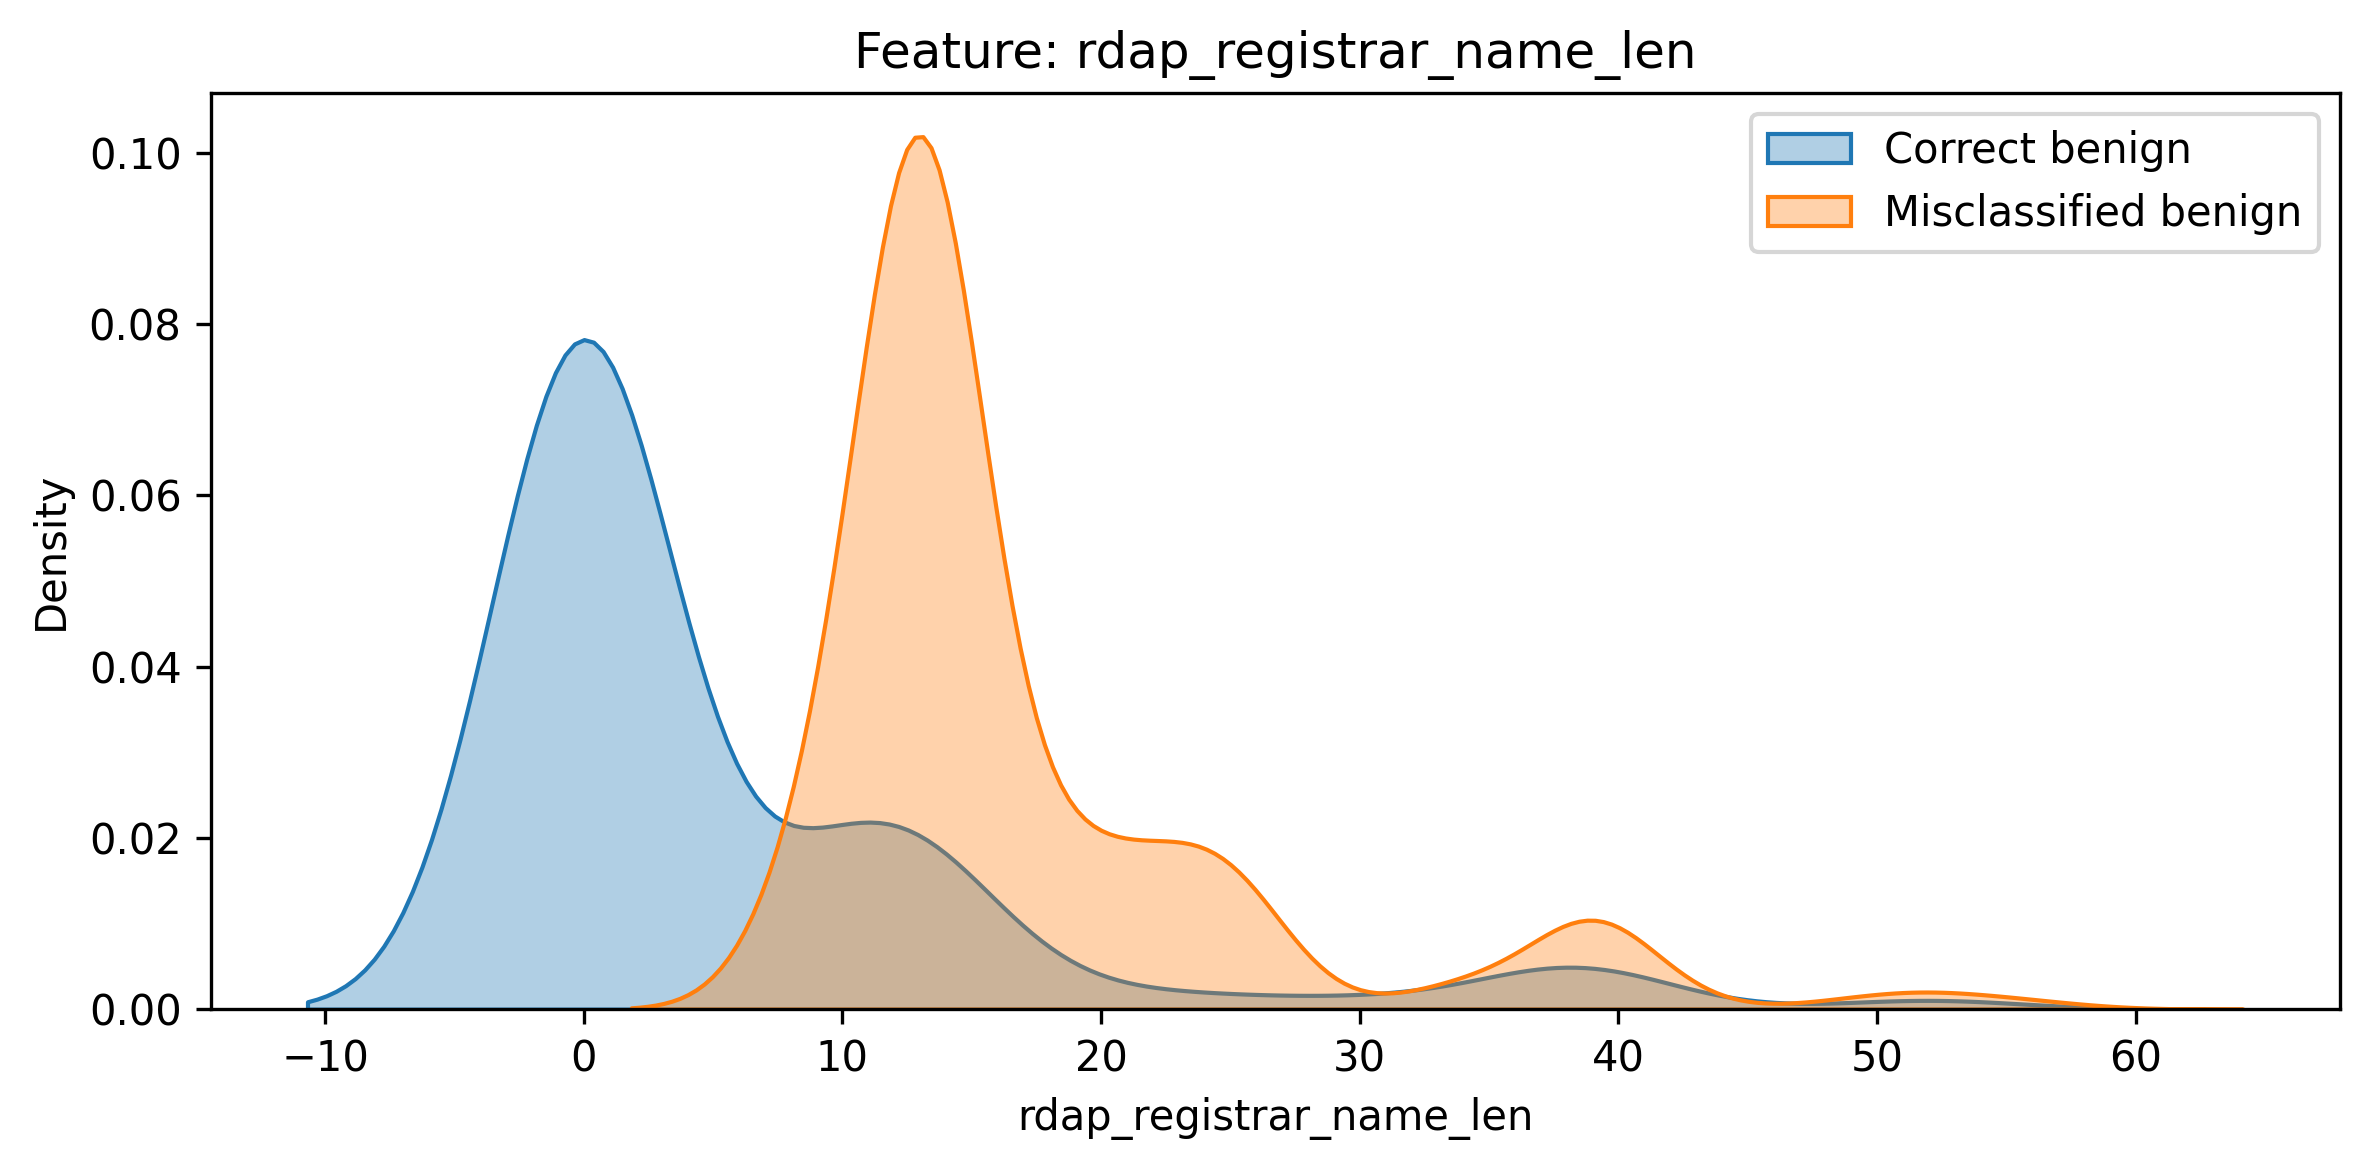

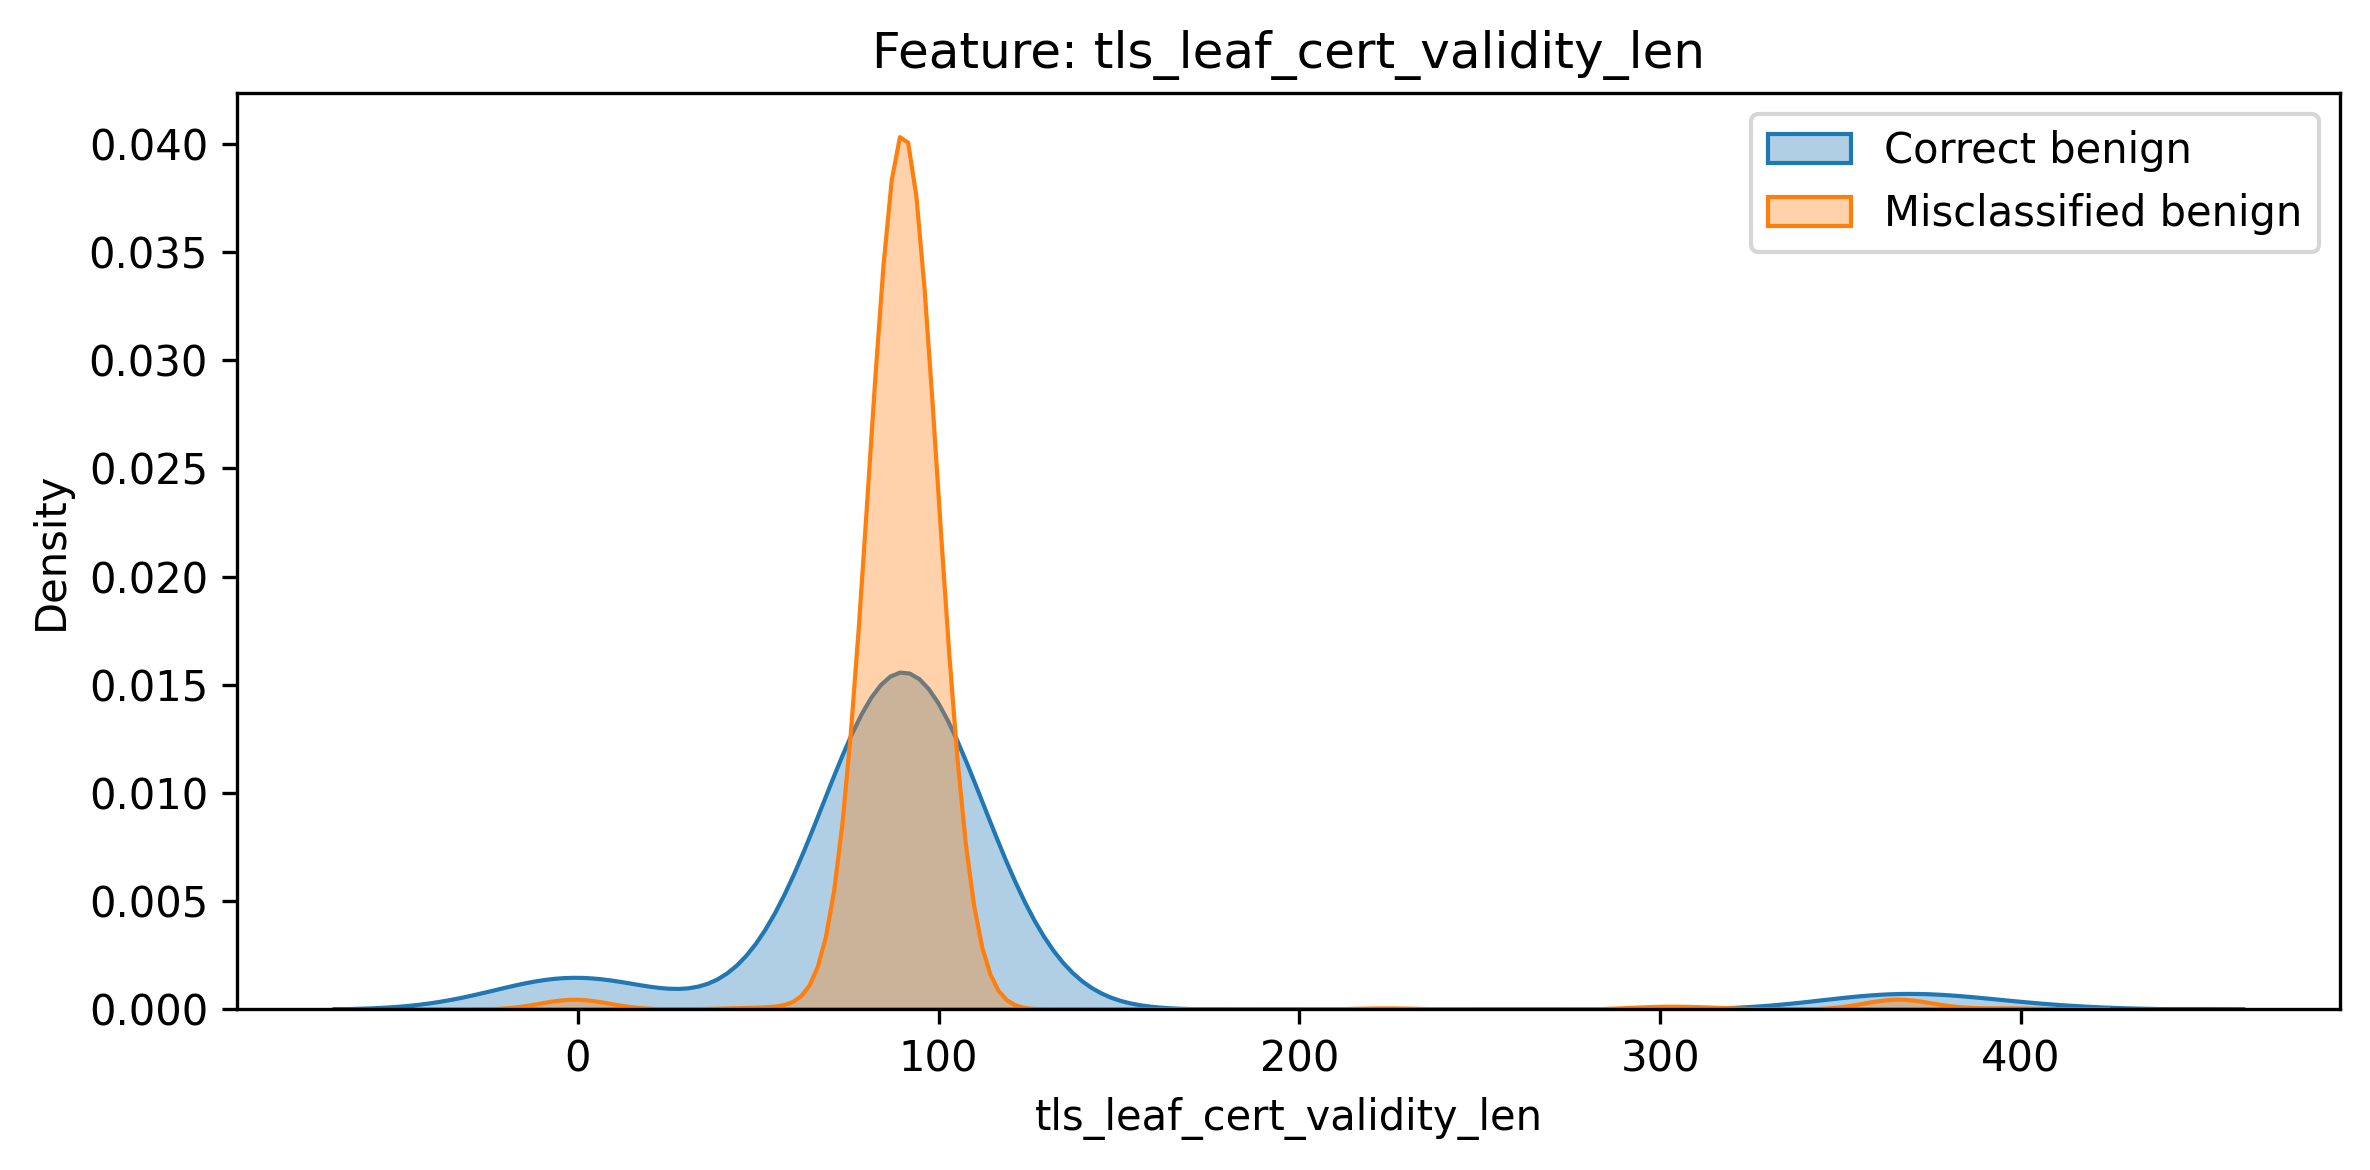

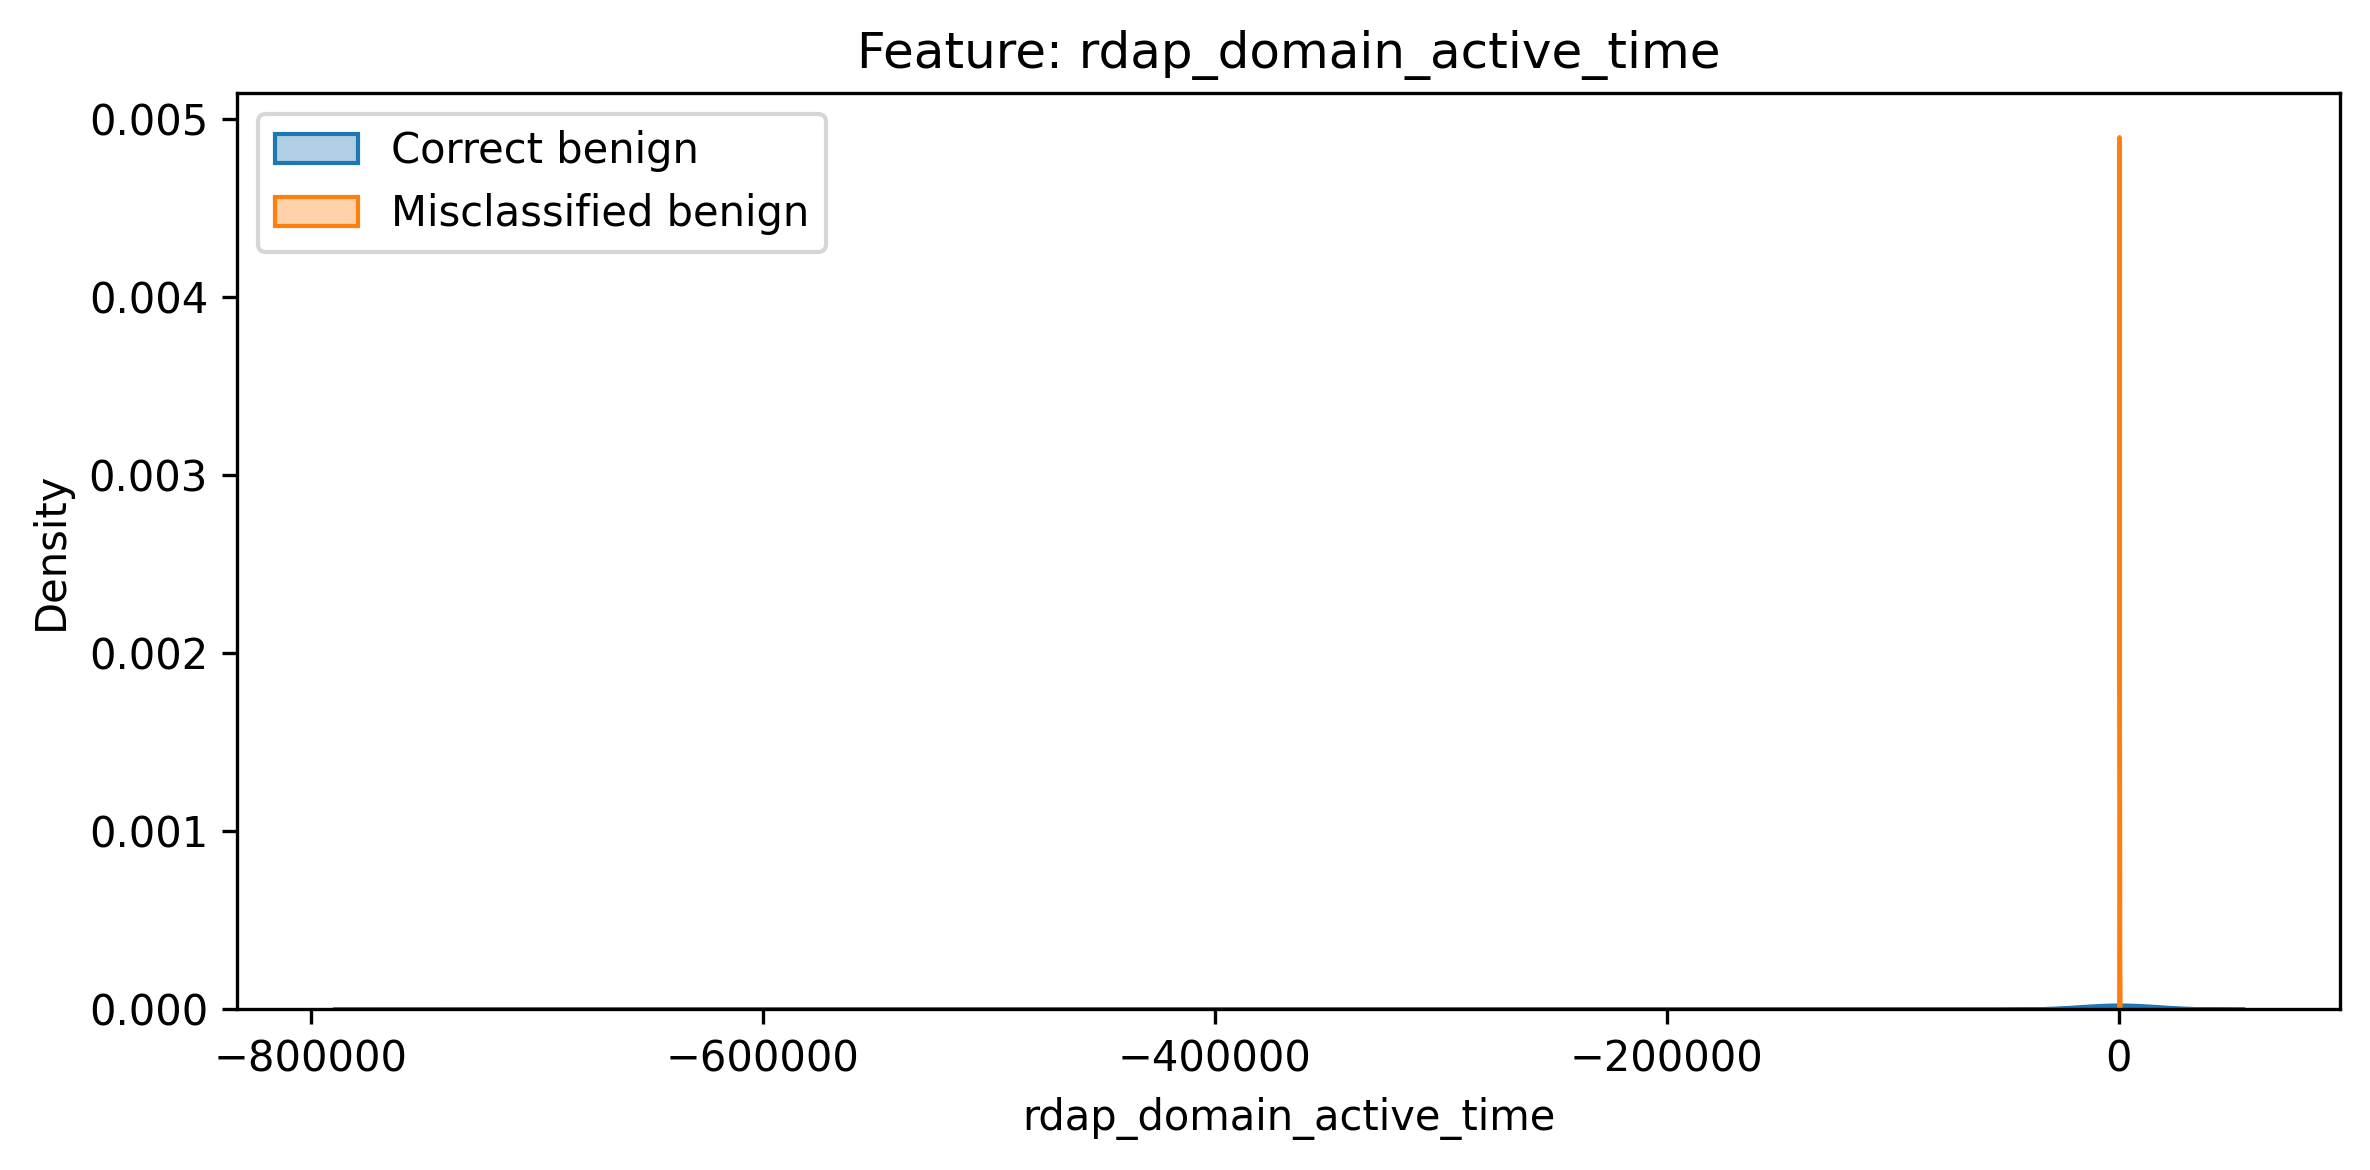

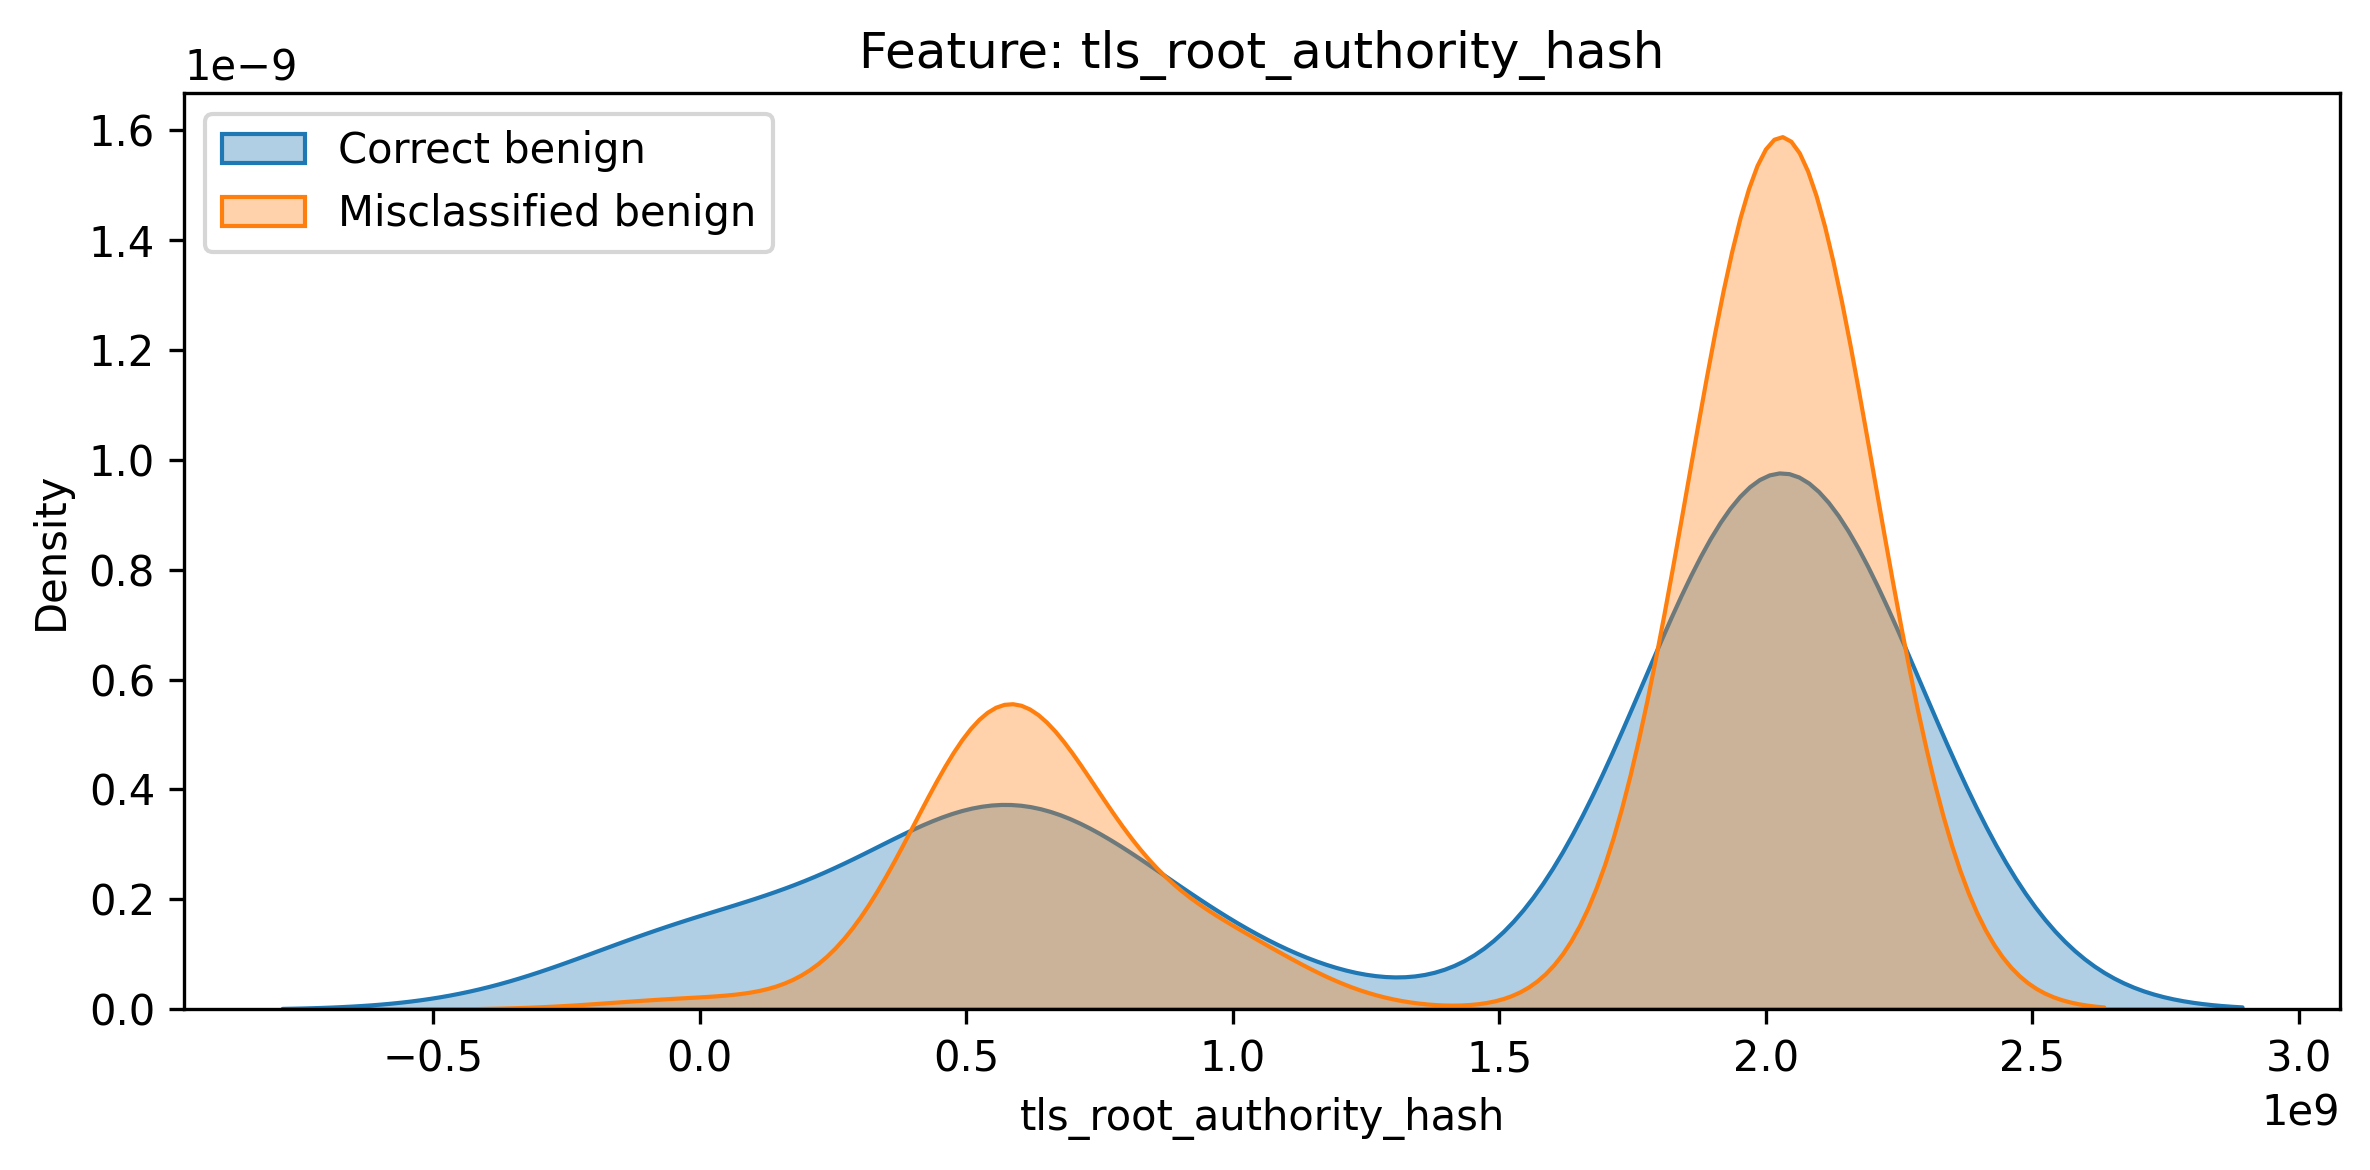

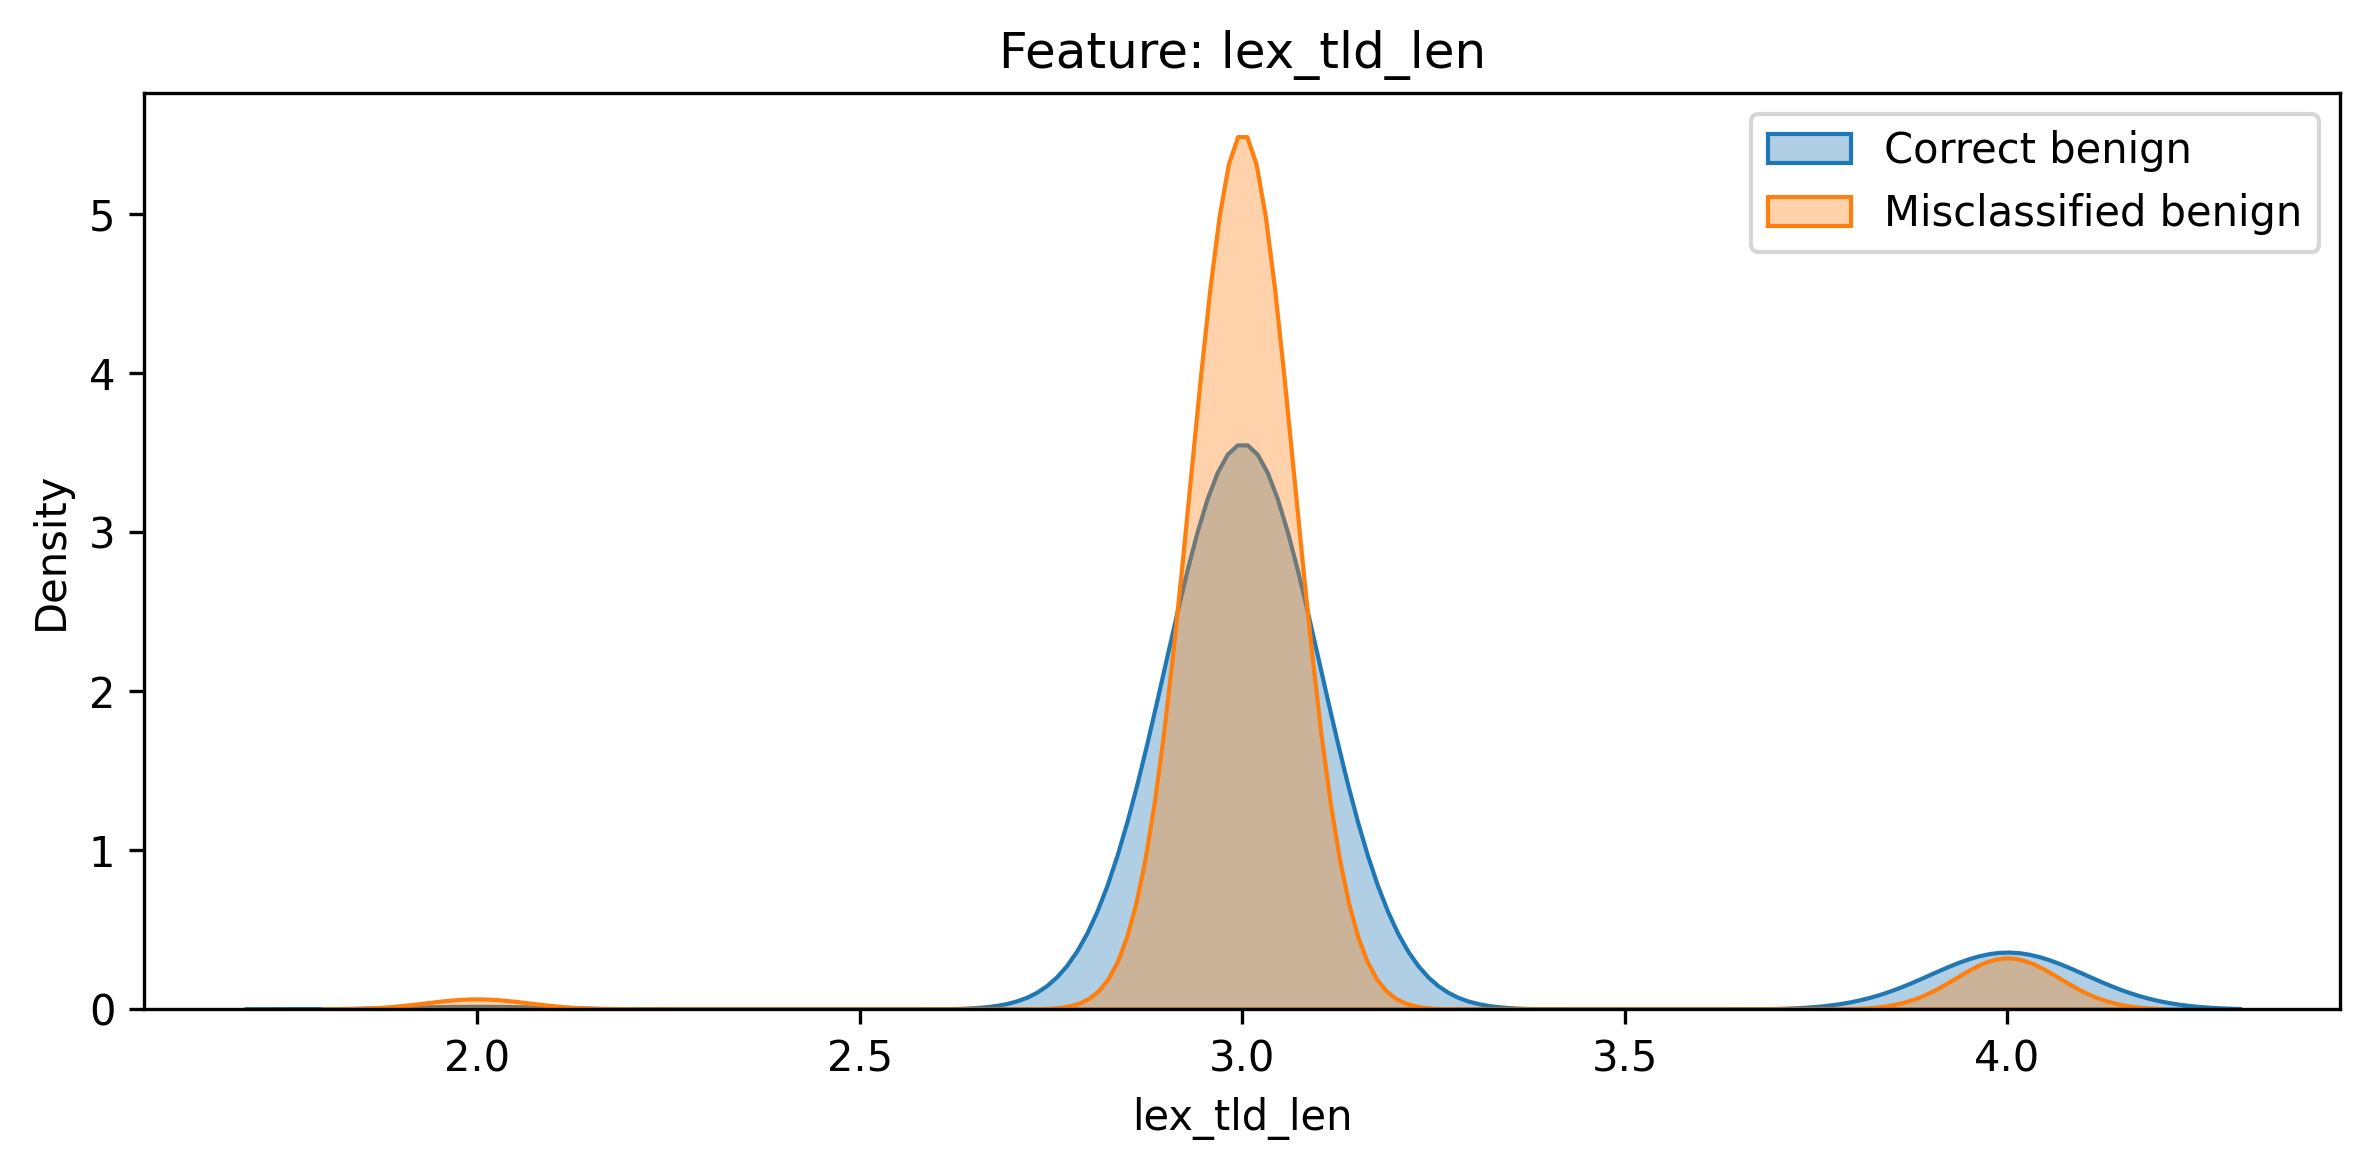

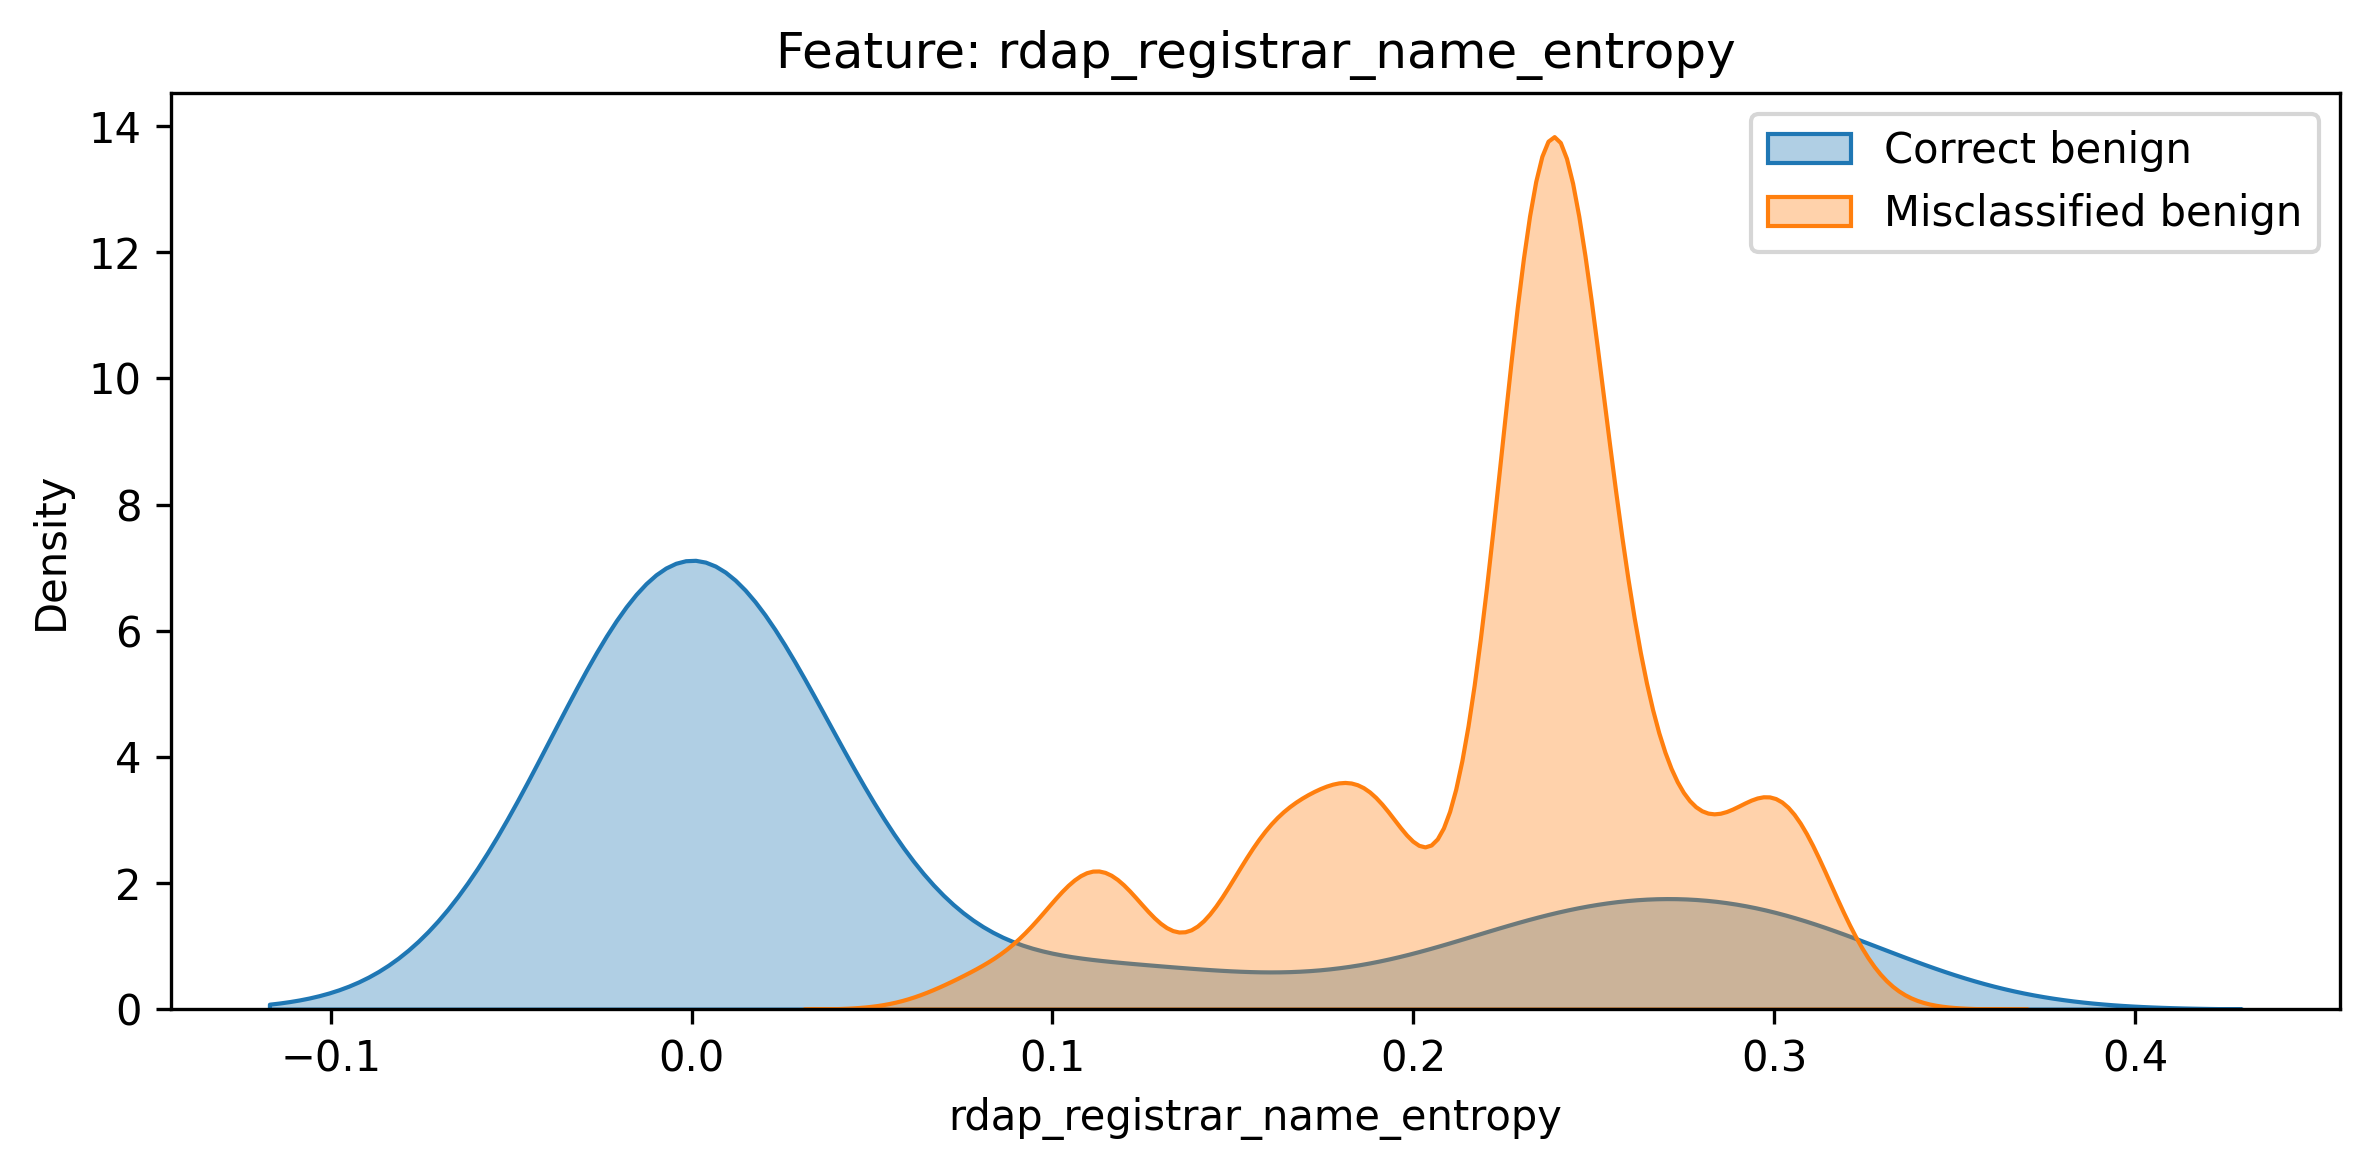

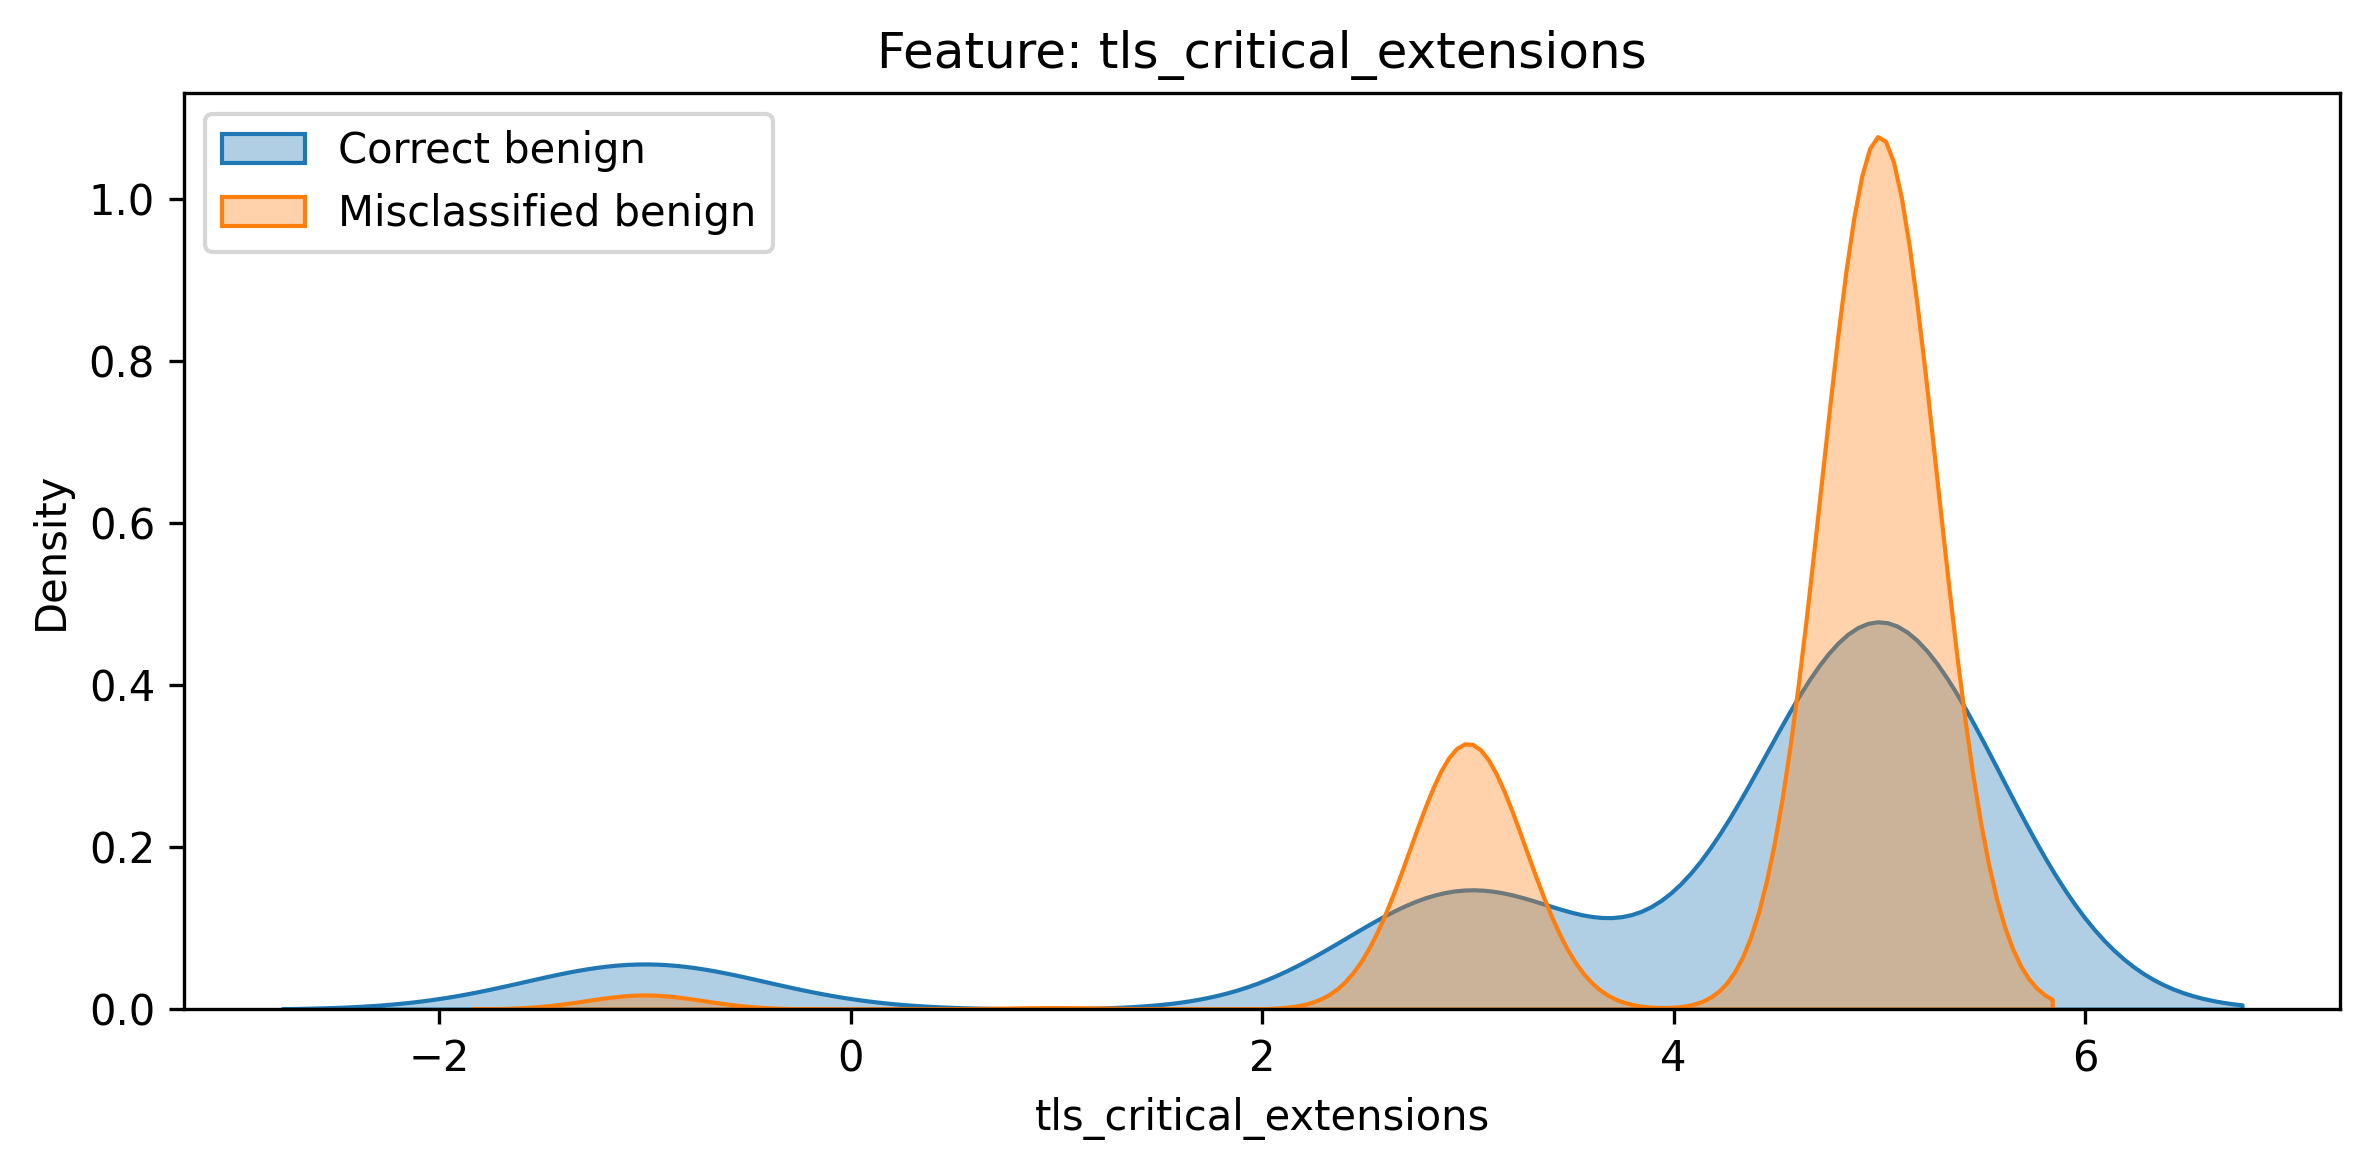

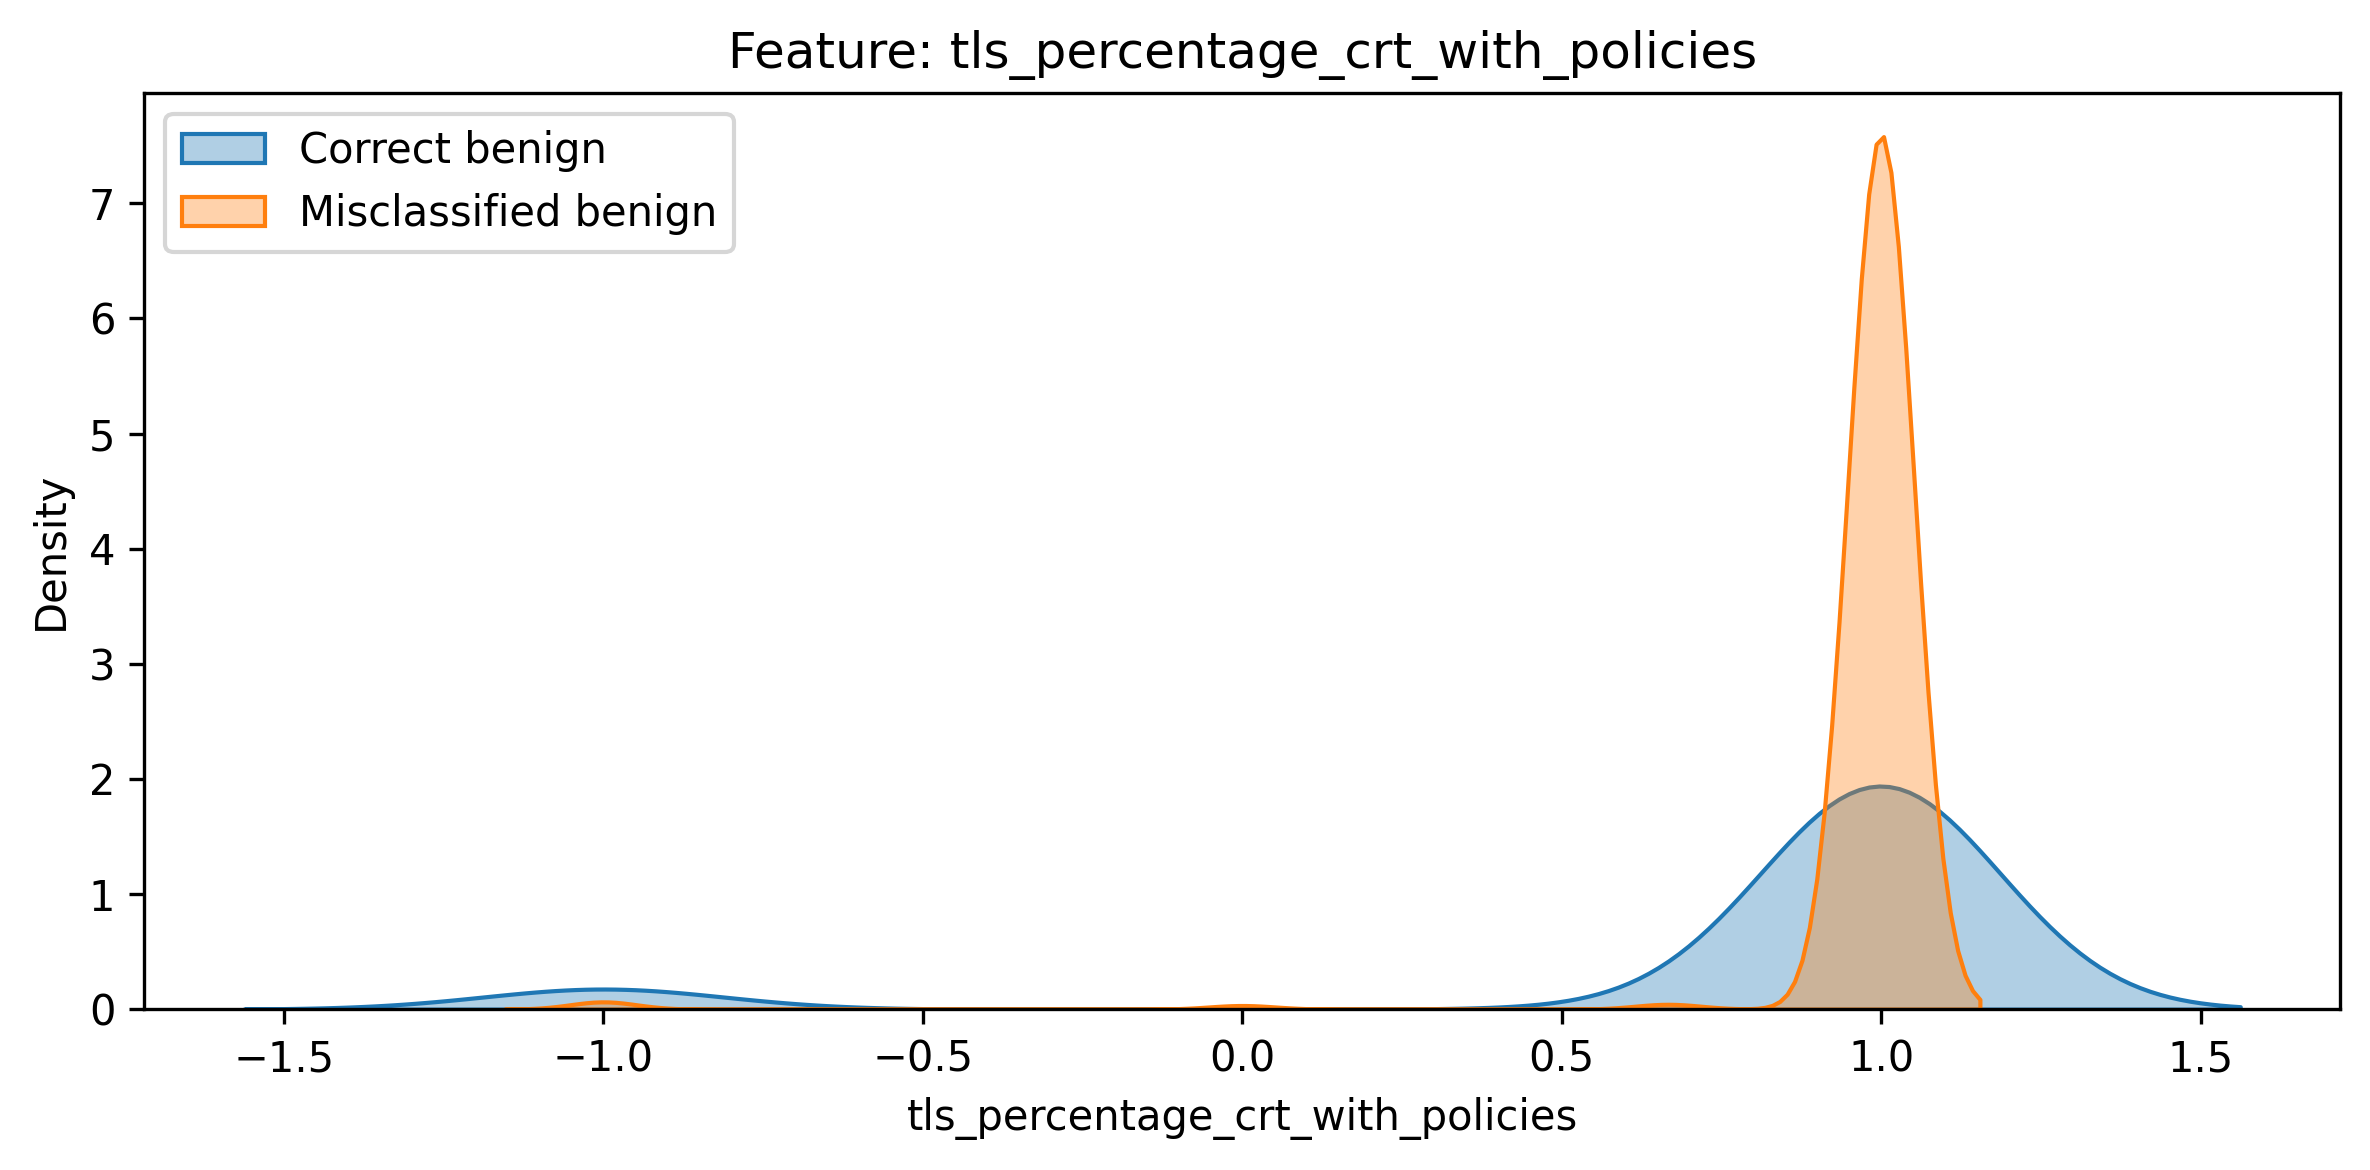

[rdap_domain_age] No threshold extracted; mis_mean=159, correct_mean=101
[lex_tld_abuse_score] No threshold extracted; mis_mean=0.503, correct_mean=0.487
[rdap_registrar_name_len] No threshold extracted; mis_mean=17.3, correct_mean=5.45
[tls_leaf_cert_validity_len] No threshold extracted; mis_mean=93.4, correct_mean=95.4
[rdap_domain_active_time] No threshold extracted; mis_mean=159, correct_mean=-3.28e+03
[tls_root_authority_hash] No threshold extracted; mis_mean=1.6e+09, correct_mean=1.47e+09
[lex_tld_len] No threshold extracted; mis_mean=3.04, correct_mean=3.09
[rdap_registrar_name_entropy] No threshold extracted; mis_mean=0.223, correct_mean=0.0713
[tls_critical_extensions] No threshold extracted; mis_mean=4.46, correct_mean=4.08
[tls_percentage_crt_with_policies] No threshold extracted; mis_mean=0.978, correct_mean=0.833


In [21]:
analysis = analyze_problematic_features(model, df_validation, misclassified, top_k=10)
for feat, info in analysis.items():
    print(info["suggestion"])
